In [164]:
import json
from pathlib import Path
import jax
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import serialization as sz
import pandas as pd
from numpyro.infer import NUTS, MCMC, init_to_median
import jax.random as jr
import numpyro
import numpyro.distributions as dist

from model import (
    MiniGPJax,
    # kernel / mean / likelihood classes
    RBF, Matern32, GaussianLikelihood, ZeroMean, GPParams, Standardizer,
    # state (de)serializers defined in your file
    _kernel_to_state, _kernel_from_state,
    _lik_to_state, _lik_from_state,
    _zeromean_to_state, _zeromean_from_state,
    _gpparams_to_state, _gpparams_from_state,
    _std_to_state, _std_from_state,
)
from model import MiniGPJax, _register_all_serializers_once
_register_all_serializers_once()

In [90]:
TRAIN_CSV = "11_13_25_train_set.csv"#Completed_train_set_10_30_25.csv#"Train_Set_2.csv"
TEST_CSV  = "11_13_25_test_set.csv"#"Test_Set_2.csv"
CKPT_DIR  = "ckpts/gp_run_004"
dim = 5
gp = MiniGPJax(
    dim=dim,
    kernel="rbf",            # or "matern32" I dont have the others
    fixed_noise=None,        # consider None to learn noise for better generalization
    standardize_x=True,
    standardize_y=True,
    log_y=True,              # ensures: log -> standardize (train stats) -> fit
    jitter=1e-6,
)
gp.load(TRAIN_CSV, TEST_CSV)
gp.fit(lbfgs_max_iter=30, lbfgs_tol=1e-7, num_restarts=1, seed=10)

#

[ok] Loaded train: X=(1024, 5), y=(1024,) (log→std)
[ok] Loaded test:  X=(256, 5), y=(256,) (log→std)
[restart 0] nLML = -1943.275146
[ok] Best nLML = -1943.275146
[fit] amp=1.482 | noise_var=9.691e-06 | ell=[ 5.489  2.183 28.434  0.347  2.138]
[fit] train RMSE(z)=0.0027 | R²(z)=1.0000  (z = standardized)


In [91]:
gp.evaluate_and_plot(outdir="11_16_25")  # defaults to "log" when log_y=True


[eval:log] RMSE(log)=0.021460 | MAE(log)=0.010059 | R²(log)=0.999637


{'rmse_log': 0.021460197865962982,
 'mae_log': 0.010059233754873276,
 'r2_log': 0.9996371125229039}

In [107]:
_register_all_serializers_once()
gp.save_checkpoint(CKPT_DIR)

[save] Wrote checkpoint to: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_004


In [108]:



CKPT_DIR = "ckpts/gp_run_004"
TRAIN_CSV = "11_13_25_train_set.csv"
_register_all_serializers_once()
gp_loaded = MiniGPJax.ready_from_checkpoint(CKPT_DIR, train_csv=TRAIN_CSV, rebuild=True)

[load] Loaded config+params from: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_004
[posterior] Rebuilt training posterior.


# Sanity check

In [371]:
x_single = np.array([[0.68,4823,0.39,9.1,3.45E-07]], dtype=np.float32)  # shape (1, 5)

mu, std = gp_loaded.predict(x_single)
print(mu/1e7, std/1e7)

[0.22035122] [0.00123849]


In [110]:

def _gp_predict_mean_jax(Xnew: jnp.ndarray) -> jnp.ndarray:
    """
    JAX-only version of gp.predict that returns the predictive MEAN
    in original y units (with log_y lognormal correction if needed).

    Xnew: (N, dim) jnp array
    Returns: (N,) jnp array
    """
    # Standardize X with the fitted Standardizer
    Xn = gp_loaded.std.transform_X(Xnew)

    # Posterior in z-space (standardized log(y) if log_y=True)
    mean_z, std_z = gp_loaded.posterior.predict(Xn, include_noise=True)  # both jnp

    # Undo standardization (still log-space if log_y=True)
    mean_z, std_z = gp_loaded.std.inverse_y(mean_z, std_z)

    if gp_loaded.log_y:
        # log-normal moment correction (same as gp.predict)
        mu    = mean_z
        sigma = std_z
        y_mean = jnp.exp(mu + 0.5 * (sigma ** 2))  # E[Y]
        return y_mean  # (N,)
    else:
        return mean_z  # (N,)


def gp_single_x(x1, x2, x3, x4, x5):
    x = jnp.stack([x1, x2, x3, x4, x5])
    #return(x.shape)
    return _gp_predict_mean_jax(jnp.array([x]))[0]

gp_flow_maps = jax.vmap(gp_single_x, (None, None, None, None, 0))

In [111]:
_gp_predict_mean_jax(x_single)



Array([2161028.5], dtype=float32)

In [696]:
flows = jnp.array([2.4e-7, 3.45e-7, 6.5e-7])
x1 =0.8
x2 = 2000
x3 = 0.0001
x4 = 4


## gp_flows_maps is the vectorized version

In [697]:

prins = gp_flow_maps(x1, x2, x3, x4, flows)/6894.76 

print(prins)

[227.41144 305.57578 514.855  ]


# process data


In [113]:
df = pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Pressure")               
df.head()

subset = df.iloc[1:, 2:6]
# Make the first row the header

new_header = subset.iloc[0]   # get the first row
subset = subset[1:]           # take the data after the header row
subset.columns = new_header   # set header
subset = subset.reset_index(drop=True)  # clean index
print(subset.head())

pressure = subset['Pump Pressure(PSI)'].values[1:]
pressure_times = subset['Time(s)'].values[1:]

1   Time(s) Extruder Pressure (PSI) Pump Pressure(PSI) Temperature(C)
0         0               687.94829         332.927429     279.594642
1  0.060966              721.002479         305.609107     279.594642
2  0.108939              747.514903         285.115698     279.594642
3  0.154912               767.74587         270.662268     279.594642
4  0.200885              781.886558          261.56303     279.594642


(array([1.000e+00, 1.000e+00, 1.119e+03, 7.230e+02, 1.200e+01, 7.800e+01,
        1.363e+03, 4.850e+02, 1.000e+00, 1.000e+00]),
 array([-2.11480363, -1.53596184, -0.95712005, -0.37827827,  0.20056352,
         0.77940531,  1.35824709,  1.93708888,  2.51593067,  3.09477245,
         3.67361424]),
 <BarContainer object of 10 artists>)

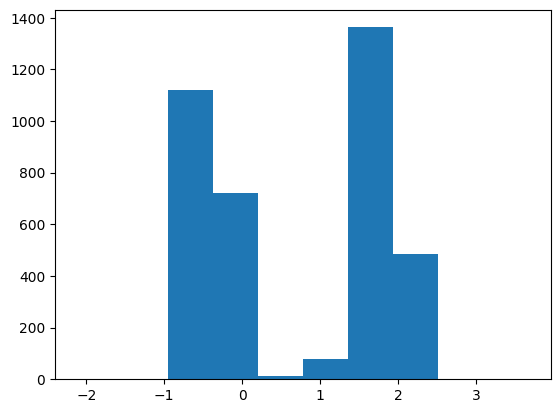

In [114]:
df= pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Position")
df.head()
columns_to_drop = [0, 1,7, 9, 10, 11, 12]

df.drop(df.columns[columns_to_drop], axis=1, inplace=True)


subset = df.iloc[1:, :]
new_header = subset.iloc[0]
subset.columns = new_header
subset = subset.reset_index(drop=True)  # clean index
subset.head()

# xreate all the ararys 

time = subset['Time(seconds)'].values[1:]
x_locs = subset['x(mm)'].values[1:]
y_locs = subset['y(mm)'].values[1:]
z_locs = subset['z(mm)'].values[1:]
speeds = subset['Speed (mm/s)'].values[1:]
flow_rates = subset['Flowrate[m^3/s]'].values[1:]

extract_flow = 2.91582835522733e-07
mask = (flow_rates > 0.96 * extract_flow) & (flow_rates < 1.04 * extract_flow)
plt.hist((flow_rates[np.argwhere(mask)] - extract_flow)/extract_flow * 100)

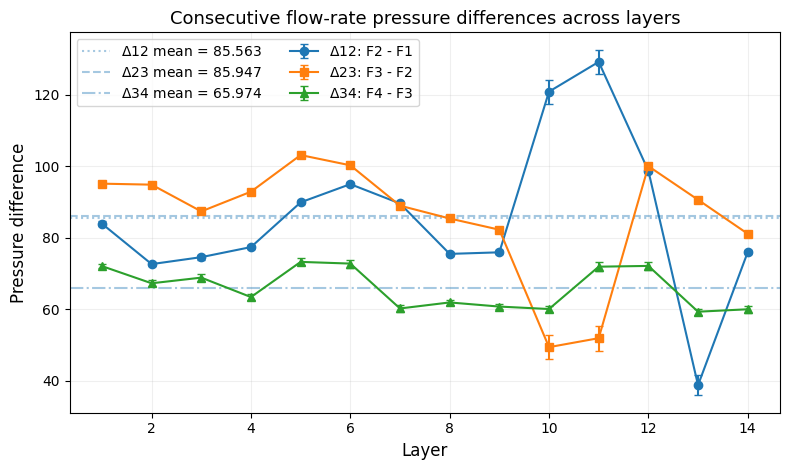

\Delta 12: mean=85.5635, std_across_layers=21.9971, n=14, median_SE=0.6142
\Delta 23: mean=85.9465, std_across_layers=16.3597, n=14, median_SE=0.6397
\Delta 34: mean=65.9743, std_across_layers=5.6731, n=14, median_SE=0.9143


In [116]:
flows = np.array([
    2.91582835522733e-07,
    4.84503201019647e-07,
    6.87113630536953e-07,
    8.89724060054260e-07,
], dtype=np.float32)

# ---------- collect per-layer steady means ----------
n_layers = 14
means = np.full((n_layers, 4), np.nan)
sems  = np.full((n_layers, 4), np.nan)

# NEW: store per-layer average measured flow for each of the 4 flow setpoints
flow_means = np.full((n_layers, 4), np.nan)
flow_sems  = np.full((n_layers, 4), np.nan)

def pick_first_key(d: dict, candidates):
    for k in candidates:
        if k in d and d[k] is not None:
            return d[k]
    return None

for layer in range(1, n_layers + 1):
    for k, flow in enumerate(flows):
        res = extract_layer_data(
            layer=layer,
            layer_height=1.5,
            z_locs=z_locs,
            time=time,
            speeds=speeds,
            flow_rates=flow_rates,
            pressure_times=pressure_times,
            pressure=pressure,
            extract_flow=flow,
            flow_sensor_error_percentage=4.0,
        )

        # ----- pressure steady-state stats (existing) -----
        pt = res["pressure_times_ss"]
        pv = res["pressures_ss"]
        m, se = steady_mean_of_segment(pt, pv)
        means[layer-1, k] = m
        sems[layer-1, k]  = se

        # ----- flow steady-state stats (NEW) -----
        # Try to read steady-state flow directly if provided by extract_layer_data
        ft = pick_first_key(res, ["flow_times_ss", "flowrate_times_ss", "flow_rate_times_ss"]) or pt
        fv = pick_first_key(res, ["flow_rates_ss", "flowrate_ss", "flows_ss", "flow_ss"])

        if fv is None:
            # Fallback: estimate from the raw flow_rates around the commanded flow ± sensor error,
            # within the same time indices used for pressure steady-state, if available.
            # Try to get the boolean mask / indices for the steady window:
            mask_ss = pick_first_key(res, ["mask_ss", "steady_mask", "ss_mask"])
            if mask_ss is not None and mask_ss.shape == flow_rates.shape:
                cand = flow_rates[mask_ss]
            else:
                # last-resort: just band around the setpoint across all samples
                band = 0.04 * flow
                mask = (flow_rates > (flow - band)) & (flow_rates < (flow + band))
                cand = flow_rates[mask]

            if cand.size > 1:
                fm, fse = float(np.mean(cand)), float(np.std(cand, ddof=1) / np.sqrt(cand.size))
            elif cand.size == 1:
                fm, fse = float(cand[0]), np.nan
            else:
                fm, fse = np.nan, np.nan
        else:
            # We have steady-state flow vector fv (and possibly its times ft)
            fm, fse = steady_mean_of_segment(ft, fv)

        flow_means[layer-1, k] = fm
        flow_sems[layer-1, k]  = fse

# ---------- consecutive differences & error propagation (unchanged) ----------
d12 = means[:, 1] - means[:, 0]
d23 = means[:, 2] - means[:, 1]
d34 = means[:, 3] - means[:, 2]

sd12 = np.sqrt(sems[:, 1]**2 + sems[:, 0]**2)
sd23 = np.sqrt(sems[:, 2]**2 + sems[:, 1]**2)
sd34 = np.sqrt(sems[:, 3]**2 + sems[:, 2]**2)

layers = np.arange(1, n_layers + 1)

# ---------- plot (unchanged) ----------
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(layers, d12, yerr=sd12, fmt='o-', capsize=3, label=r'$\Delta 12$: F2 - F1')
ax.errorbar(layers, d23, yerr=sd23, fmt='s-', capsize=3, label=r'$\Delta 23$: F3 - F2')
ax.errorbar(layers, d34, yerr=sd34, fmt='^-', capsize=3, label=r'$\Delta 34$: F4 - F3')

for d, name, ls in [(d12, r'$\Delta 12$ mean', ':'), (d23, r'$\Delta 23$ mean', '--'), (d34, r'$\Delta 34$ mean', '-.')]:
    mu = np.nanmean(d)
    ax.axhline(mu, linestyle=ls, alpha=0.4, label=fr'{name} = {mu:.3f}')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Pressure difference', fontsize=12)
ax.set_title('Consecutive flow-rate pressure differences across layers', fontsize=13)
ax.legend(ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------- quick numeric summary (unchanged) ----------
def summarize(name, d, sd):
    valid = np.isfinite(d)
    mu = np.nanmean(d)
    sdv = np.nanstd(d, ddof=1)
    print(f"{name}: mean={mu:.4f}, std_across_layers={sdv:.4f}, "
          f"n={valid.sum()}, median_SE={np.nanmedian(sd):.4f}")

summarize(r"\Delta 12", d12, sd12)
summarize(r"\Delta 23", d23, sd23)
summarize(r"\Delta 34", d34, sd34)

# ---------- NEW: per-layer average flow arrays ----------
f1, f2, f3, f4 = (flow_means[:, 0], flow_means[:, 1], flow_means[:, 2], flow_means[:, 3])

In [117]:


x1 =0.64
x2 = 4823
x3 = 0.0039
x4 = 9.9

pres_f1 = gp_flow_maps(x1, x2, x3, x4, f1)
pres_f2 = gp_flow_maps(x1, x2, x3, x4, f2)
pres_f3 = gp_flow_maps(x1, x2, x3, x4, f3)
pres_f4 = gp_flow_maps(x1, x2, x3, x4, f4)

print(pres_f1/ 6894.76)
print(pres_f2/ 6894.76)
print(pres_f3/ 6894.76)
print(pres_f4/ 6894.76)

[223.80464 223.7421  223.68068 223.85117 223.75832 223.80464 223.7579
 223.80464 223.7739  223.71928 223.78905 223.82811 223.72717 223.69582]
[310.26538 310.58804 310.46988 310.3938  310.82483 310.29733 310.62064
 310.37277 310.42636 310.3938  310.4909  310.44797 310.36246 310.36215]
[387.40845 386.99966 387.22046 386.87863 387.07312 386.979   387.1466
 387.2877  387.00632 387.1407  387.26108 387.25443 387.0329  387.2345 ]
[449.13647 449.0662  448.87268 448.98056 448.92746 448.8645  449.14545
 449.04306 449.6666  449.09787 449.4012  449.05038 449.01266 449.2067 ]


In [118]:
print(pres_f2/6894.76 - pres_f1/ 6894.76)
print(pres_f3/ 6894.76 - pres_f2/ 6894.76)
print(pres_f4/ 6894.76 - pres_f3/ 6894.76)



[86.46074  86.84595  86.7892   86.54263  87.06651  86.49269  86.86273
 86.56813  86.652466 86.674515 86.70186  86.61986  86.635284 86.666336]
[77.14307  76.41162  76.75058  76.48483  76.24829  76.68167  76.52597
 76.91492  76.579956 76.74689  76.77017  76.80646  76.67044  76.872345]
[61.728027 62.06653  61.65222  62.10193  61.85434  61.885498 61.99884
 61.75537  62.66028  61.957184 62.140137 61.79596  61.979767 61.9722  ]


## some variables need to be re arranged

In [156]:
F = jnp.concatenate([f1[:, None],f2[:, None],f3[:, None],f4[:, None]], axis =1)

D = jnp.concatenate([d12[:, None], d23[:, None], d34[:, None]], axis = 1)

D.shape

(14, 3)

## Sanity checks please

In [154]:
# flows = jnp.array([2.4e-7, 3.45e-7, 6.5e-7])
x1 =0.66
x2 = 3800
x3 = 0.0039
x4 = 9.9


prins1 = gp_flow_maps(x1, x2, x3, x4, F[:, 2])
prins2 = gp_flow_maps(x1, x2, x3, x4, F[:, 3])
print(prins2/6894.76- prins1/6894.76)

[59.82135  59.36676  59.487915 59.725708 59.784363 59.67035  59.7565
 59.8067   60.052765 59.252533 59.249023 59.686676 59.653137 59.97708 ]


### Will probably need limits of x1 to x4 to ensure we dont go beyond GP training.

## could always sample in beta and then transform

In [175]:
import jax
import jax.numpy as jnp

def gp_flow_maps(x1, x2, x3, x4, flows):
    """
    x1, x2, x3, x4: scalars (hyperparameters)
    flows: (N,) array of flow rates
    returns: (N,) predicted pressures in SAME units as _gp_predict_mean_jax
    """
    flows = jnp.asarray(flows)
    N = flows.shape[0]

    x1_col = jnp.full((N,), x1)
    x2_col = jnp.full((N,), x2)
    x3_col = jnp.full((N,), x3)
    x4_col = jnp.full((N,), x4)

    # Xnew: (N, 5) = [x1, x2, x3, x4, flow]
    Xnew = jnp.stack([x1_col, x2_col, x3_col, x4_col, flows], axis=-1)

    return _gp_predict_mean_jax(Xnew)  # already returns (N,)

# (optional but often helpful)
gp_flow_maps = jax.jit(gp_flow_maps)

In [751]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

# Physical bounds (used in transforms)
x_lb = jnp.array([0.34, 1e3, 1e-3, 1e-2])
x_ub = jnp.array([0.9,  1e4, 10.0, 10.0])


def model_calibrate_diffs(F, D):
    """
    Bayesian calibration using Δ12 (F2 - F1) only.

    F : (N, 4) array of flow rates
    D : (N, 3) array of measured pressure differences in psi
        D[:, 0] is Δ12.
    """

    # -------- PRIORS ON x1..x4 (TRANSFORMED SPACE) --------
    #x1 = numpyro.sample("x1", dist.Normal(0.4*100, 0.3*100))
    x2 = numpyro.sample("x2", dist.Normal(5e4, 1e4))
    z3 = numpyro.sample("z3", dist.Normal(-2., 3.))# -4, 2
    #z4 = numpyro.sample("z4", dist.Normal(2.2, 1))
    

    x3 = jnp.exp(z3)
    
    u = numpyro.sample("u", dist.Normal(0., 1.))   # along ridge
    v = numpyro.sample("v", dist.Normal(0., 1.))   # across ridge
    x1 = 100*(0.4 + 0.1 * u)
    x4 = 9.2 + 0.5 * u + 0.3 * v   # a = slope of x4 vs x1 you see in scatter
    #x4 = z4*x1/10. # 9.9 previosuly 

    # -------- GP PREDICTIONS (Δ12 ONLY) --------
    f1_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76  # psi
    f2_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76  # psi
    f3_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76  # psi
    f4_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76  # psi
    
    d21_pred = f2_pres_pred - f1_pres_pred
    d32_pred = f3_pres_pred - f2_pres_pred
    d43_pred = f4_pres_pred - f3_pres_pred
    
    
    if D is not None:
                
        d21_obs  = D[:, 0]
        d32_obs  = D[:, 1]
        d43_obs  = D[:, 2]
    else:
        d21_obs  = None
        d32_obs  = None
        d43_obs  = None

    # --------- BIAS TERMS ---------
    b21 = numpyro.sample("b21", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    b32 = numpyro.sample("b32", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    b43 = numpyro.sample("b43", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)

    m21 = d21_pred + b21
    m32 = d32_pred + b32
    m43 = d43_pred + b43

    # expose latent means as deterministic nodes
    numpyro.deterministic("m21", m21)
    numpyro.deterministic("m32", m32)
    numpyro.deterministic("m43", m43)

    # -------- NOISE MODEL (GAUSSIAN) --------
    s21 = numpyro.sample("s21", dist.HalfNormal(1.5))
    s32 = numpyro.sample("s32", dist.HalfNormal(1.5))
    s43 = numpyro.sample("s43", dist.HalfNormal(1.5))

    # Likelihood for Delta12, Delta23
    numpyro.sample("y21", dist.Normal(loc=m21, scale=s21), obs=d21_obs)
    numpyro.sample("y32", dist.Normal(loc=m32, scale=s32), obs=d32_obs)
    numpyro.sample("y43", dist.Normal(loc=m43, scale=s43), obs=d43_obs)


In [752]:
from numpyro.infer import Predictive
import jax.random as jr

# draw samples from the prior
prior_pred = Predictive(model_calibrate_diffs, num_samples=2000)
prior_samples = prior_pred(jr.PRNGKey(0), F, None)

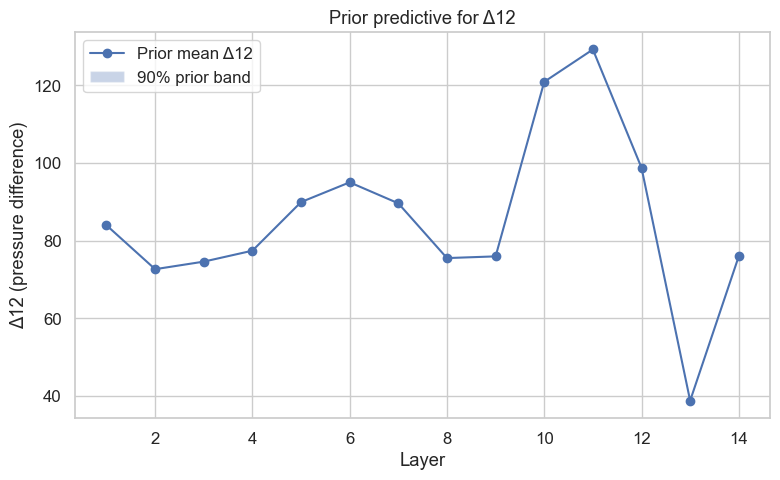

In [753]:
import matplotlib.pyplot as plt

# summary across prior samples
mean_prior = y21_prior.mean(axis=0)
p5_prior   = np.percentile(y21_prior, 5, axis=0)
p95_prior  = np.percentile(y21_prior, 95, axis=0)

layers = np.arange(1, y21_prior.shape[1] + 1)

plt.figure(figsize=(8,5))
plt.plot(layers, mean_prior, label="Prior mean Δ12", marker="o")
plt.fill_between(layers, p5_prior, p95_prior, alpha=0.3, label="90% prior band")

plt.xlabel("Layer")
plt.ylabel("Δ12 (pressure difference)")
plt.title("Prior predictive for Δ12")
plt.legend()
plt.tight_layout()
plt.show()


In [754]:
def run_nuts_calibration(
    F, D,
    seed=77, warmup=500, samples=1000, chains=2,
    target_accept=0.70, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F[:8, :], D[:8, :])
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D)
samples = mcmc.get_samples()


sample: 100%|█████████████████████████████████████████████████████| 1500/1500 [11:32:52<00:00, 27.72s/it, 127 steps of size 3.69e-02. acc. prob=0.82]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       b21      1.67      5.53      1.66     -7.24     10.83   1012.20      1.00
       b32      4.44      5.18      4.39     -3.98     12.50    968.52      1.00
       b43     -4.28      4.40     -4.27    -11.22      3.01   1202.31      1.00
       s21      5.29      0.67      5.26      4.23      6.35   1704.83      1.00
       s32      4.40      0.65      4.34      3.42      5.48   1943.71      1.00
       s43      3.92      0.63      3.86      2.86      4.90   1705.04      1.00
         u      2.30      0.16      2.29      2.04      2.57    792.39      1.00
         v     -0.27      0.59     -0.25     -1.29      0.64    804.14      1.00
        x2  48277.76   6532.10  48208.41  37113.00  58218.79    814.34      1.00
        z3     -2.60      2.50     -2.43     -6.52      1.65   1668.28      1.00

Number of divergences: 3


In [755]:
import numpy as np
import pandas as pd
import jax.numpy as jnp

# Get raw samples from MCMC
samples = mcmc.get_samples()

# Reconstruct physical parameters
u_samples   = samples["u"]
v_samples   = samples["v"]
x2_samples  = samples["x2"]           # still in original scale
z3_samples  = samples["z3"]           # log(x3)
b21_samples = samples["b21"]
b32_samples = samples["b32"]
b43_samples = samples["b43"]
s21_samples = samples["s21"]
s32_samples = samples["s32"]
s43_samples = samples["s43"]

# Transformations to physical space
x1_samples  = 0.4 + 0.1 * u_samples      # matches model: x1 = 100*(0.4 + 0.1*u)
x2_phys     = x2_samples / 10.0                    # if GP used x2/10.
x3_samples  = jnp.exp(z3_samples)                  # x3 = exp(z3)
x4_samples  = 9.2 + 0.5 * u_samples + 0.3 * v_samples  # 9. + 1. * 0.5 * u + 0.3 * v 

# Convert to NumPy for pandas
x1_np  = np.asarray(x1_samples)
x2_np  = np.asarray(x2_phys)
x3_np  = np.asarray(x3_samples)
x4_np  = np.asarray(x4_samples)
u_np   = np.asarray(u_samples)
v_np   = np.asarray(v_samples)
z3_np  = np.asarray(z3_samples)
b21_np = np.asarray(b21_samples)
b32_np = np.asarray(b32_samples)
b43_np = np.asarray(b43_samples)
s21_np = np.asarray(s21_samples)
s32_np = np.asarray(s32_samples)
s43_np = np.asarray(s43_samples)

# Build DataFrame
df = pd.DataFrame({
    "x1":  x1_np,
    "x2":  x2_np,
    "x3": x3_np,
    "x4":  x4_np,
    "log_x3": z3_np,
    "b21": b21_np,
    "b32": b32_np,
    "b43": b43_np,
    "s21": s21_np,
    "s32": s32_np,
    "s43": s43_np,
})

# Optional: quick peek
print(df.head())


         x1           x2        x3         x4    log_x3       b21       b32  \
0  0.644712  4277.057617  0.278989  10.312613 -1.276585  1.218043 -3.367619   
1  0.619754  5345.149414  0.006033  10.351604 -5.110484  0.035438 -0.888835   
2  0.618913  4517.690918  0.570241  10.425349 -0.561696  7.890543  5.053724   
3  0.634849  4632.161133  0.007718  10.272074 -4.864258  1.512849  1.921618   
4  0.635504  4140.715820  0.047272  10.335060 -3.051842  8.362162  3.846702   

         b43       s21       s32       s43  
0  -7.445679  5.396237  4.377477  4.432163  
1 -10.285712  5.491541  4.078527  3.282234  
2  -6.312493  6.604043  4.621201  4.958456  
3  -4.889111  4.169192  3.528701  3.783737  
4  -1.980420  4.993989  4.080876  3.400271  


## prior


In [756]:
num_prior = 2000  # or whatever

prior_pred = Predictive(model_calibrate_diffs, num_samples=num_prior)
# Note: pass only F; D will default to None inside the model
prior_samples = prior_samples

# ----- 2) Reconstruct physical parameters from prior -----
u_prior   = prior_samples["u"]
v_prior   = prior_samples["v"]
x2_prior  = prior_samples["x2"]
z3_prior  = prior_samples["z3"]
b21_prior = prior_samples["b21"]
b32_prior = prior_samples["b32"]
b43_prior = prior_samples["b43"]
s21_prior = prior_samples["s21"]
s32_prior = prior_samples["s32"]
s43_prior = prior_samples["s43"]

# Same transformations as posterior code
x1_prior  = 0.4 + 0.1 * u_prior                # GP-scale x1/100
x2_prior_phys = x2_prior / 10.0                # GP used x2/10
x3_prior  = jnp.exp(z3_prior)
x4_prior  = 9.2 + 0.5 * u_prior + 0.3 * v_prior

# Convert to NumPy
x1_p  = np.asarray(x1_prior)
x2_p  = np.asarray(x2_prior_phys)
x3_p  = np.asarray(x3_prior)
x4_p  = np.asarray(x4_prior)
z3_p  = np.asarray(z3_prior)
b21_p = np.asarray(b21_prior)
b32_p = np.asarray(b32_prior)
b43_p = np.asarray(b43_prior)
s21_p = np.asarray(s21_prior)
s32_p = np.asarray(s32_prior)
s43_p = np.asarray(s43_prior)

# ----- 3) Build prior DataFrame -----
df_prior = pd.DataFrame({
    "x1":      x1_p,
    "x2":      x2_p,
    "x3":      x3_p,
    "x4":      x4_p,
    "log_x3":  z3_p,
    "b21":     b21_p,
    "b32":     b32_p,
    "b43":     b43_p,
    "s21":     s21_p,
    "s32":     s32_p,
    "s43":     s43_p,
})

print(df_prior.head())

         x1           x2        x3        x4    log_x3       b21       b32  \
0  0.457573  4957.405273  0.303838  9.137889 -1.191261  2.307884  5.169624   
1  0.448919  5979.233887  0.003122  9.329538 -5.769379 -0.122132 -4.188577   
2  0.249714  5252.323242  2.165115  8.274053  0.772474 -1.054640  7.674141   
3  0.438283  4336.837891  0.001414  9.670922 -6.561400  7.385811 -1.166986   
4  0.335213  5519.859375  0.036442  9.217848 -3.312037  0.043295  6.794683   

         b43       s21       s32       s43  
0  -1.500058  0.303161  1.000139  0.046411  
1   4.346187  1.384874  1.123531  1.972120  
2  18.065458  1.591959  2.185307  0.740248  
3  -6.802278  2.448206  1.776147  0.732507  
4   7.740938  0.266113  0.239624  0.447475  


In [757]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

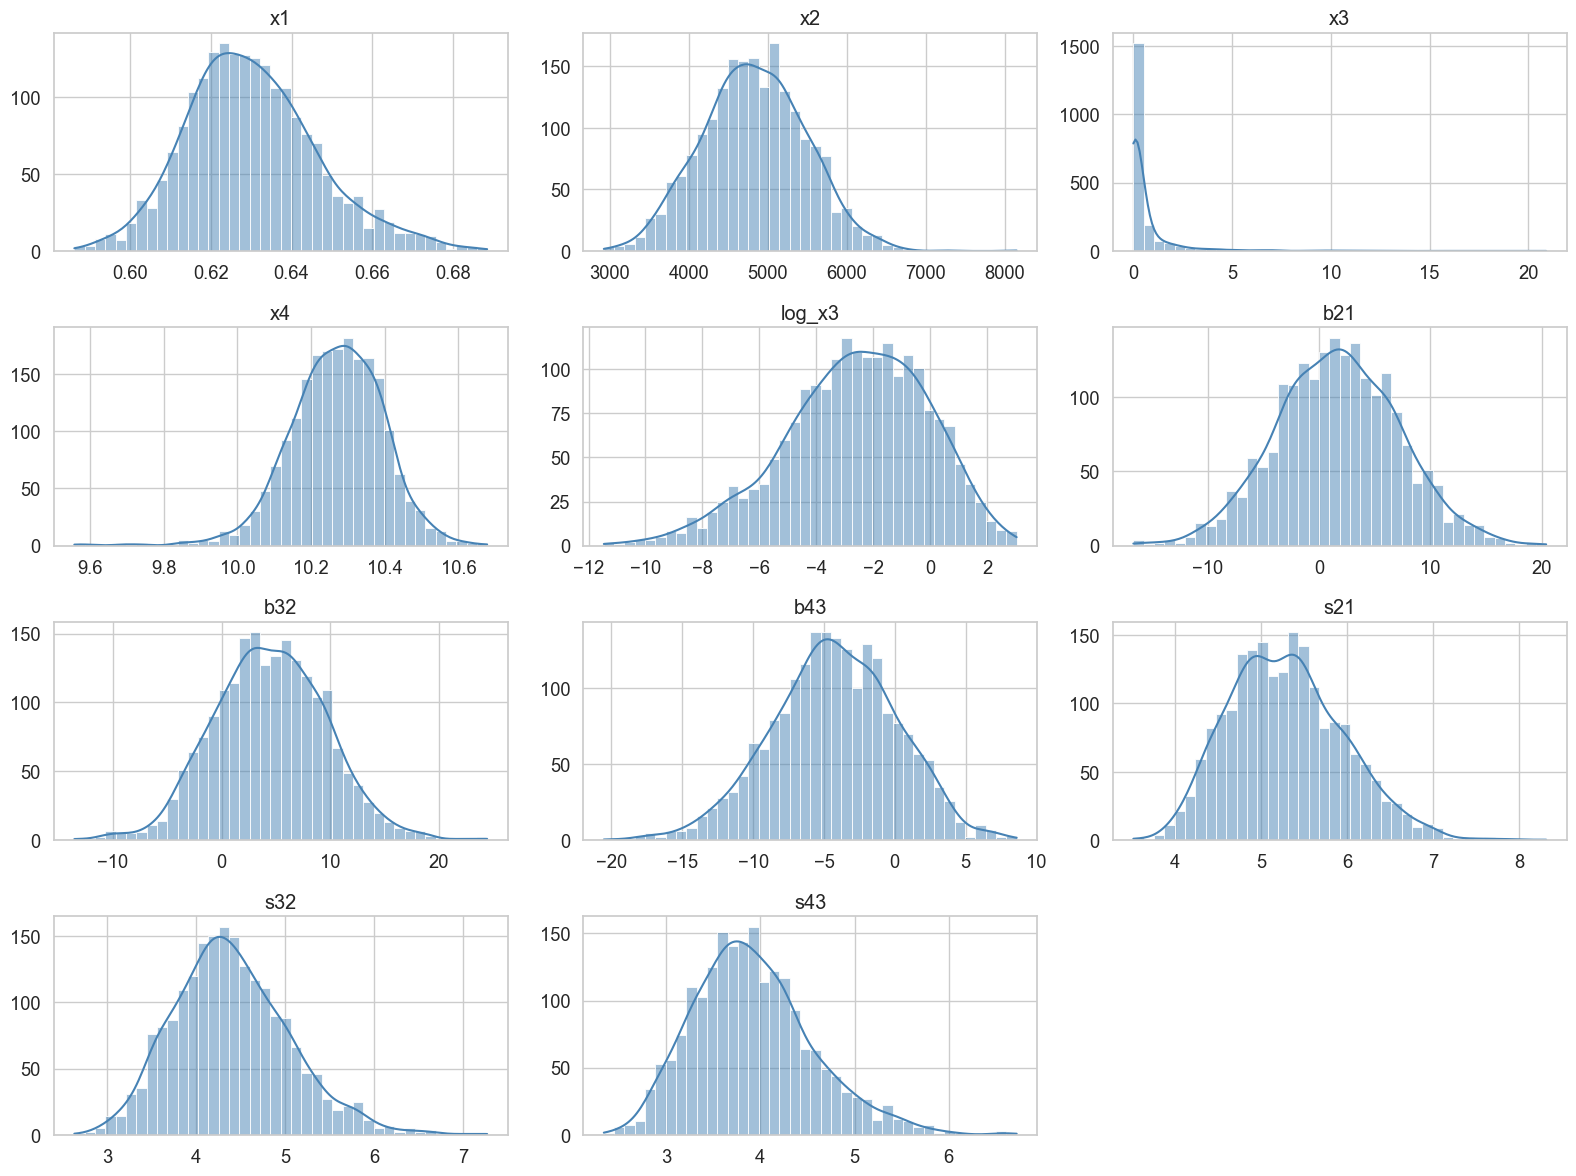

In [758]:
params = df.columns
n = len(params)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for ax, param in zip(axes, params):
    sns.histplot(df[param], bins=40, kde=True, color="steelblue", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Turn off any unused axes
for j in range(len(params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

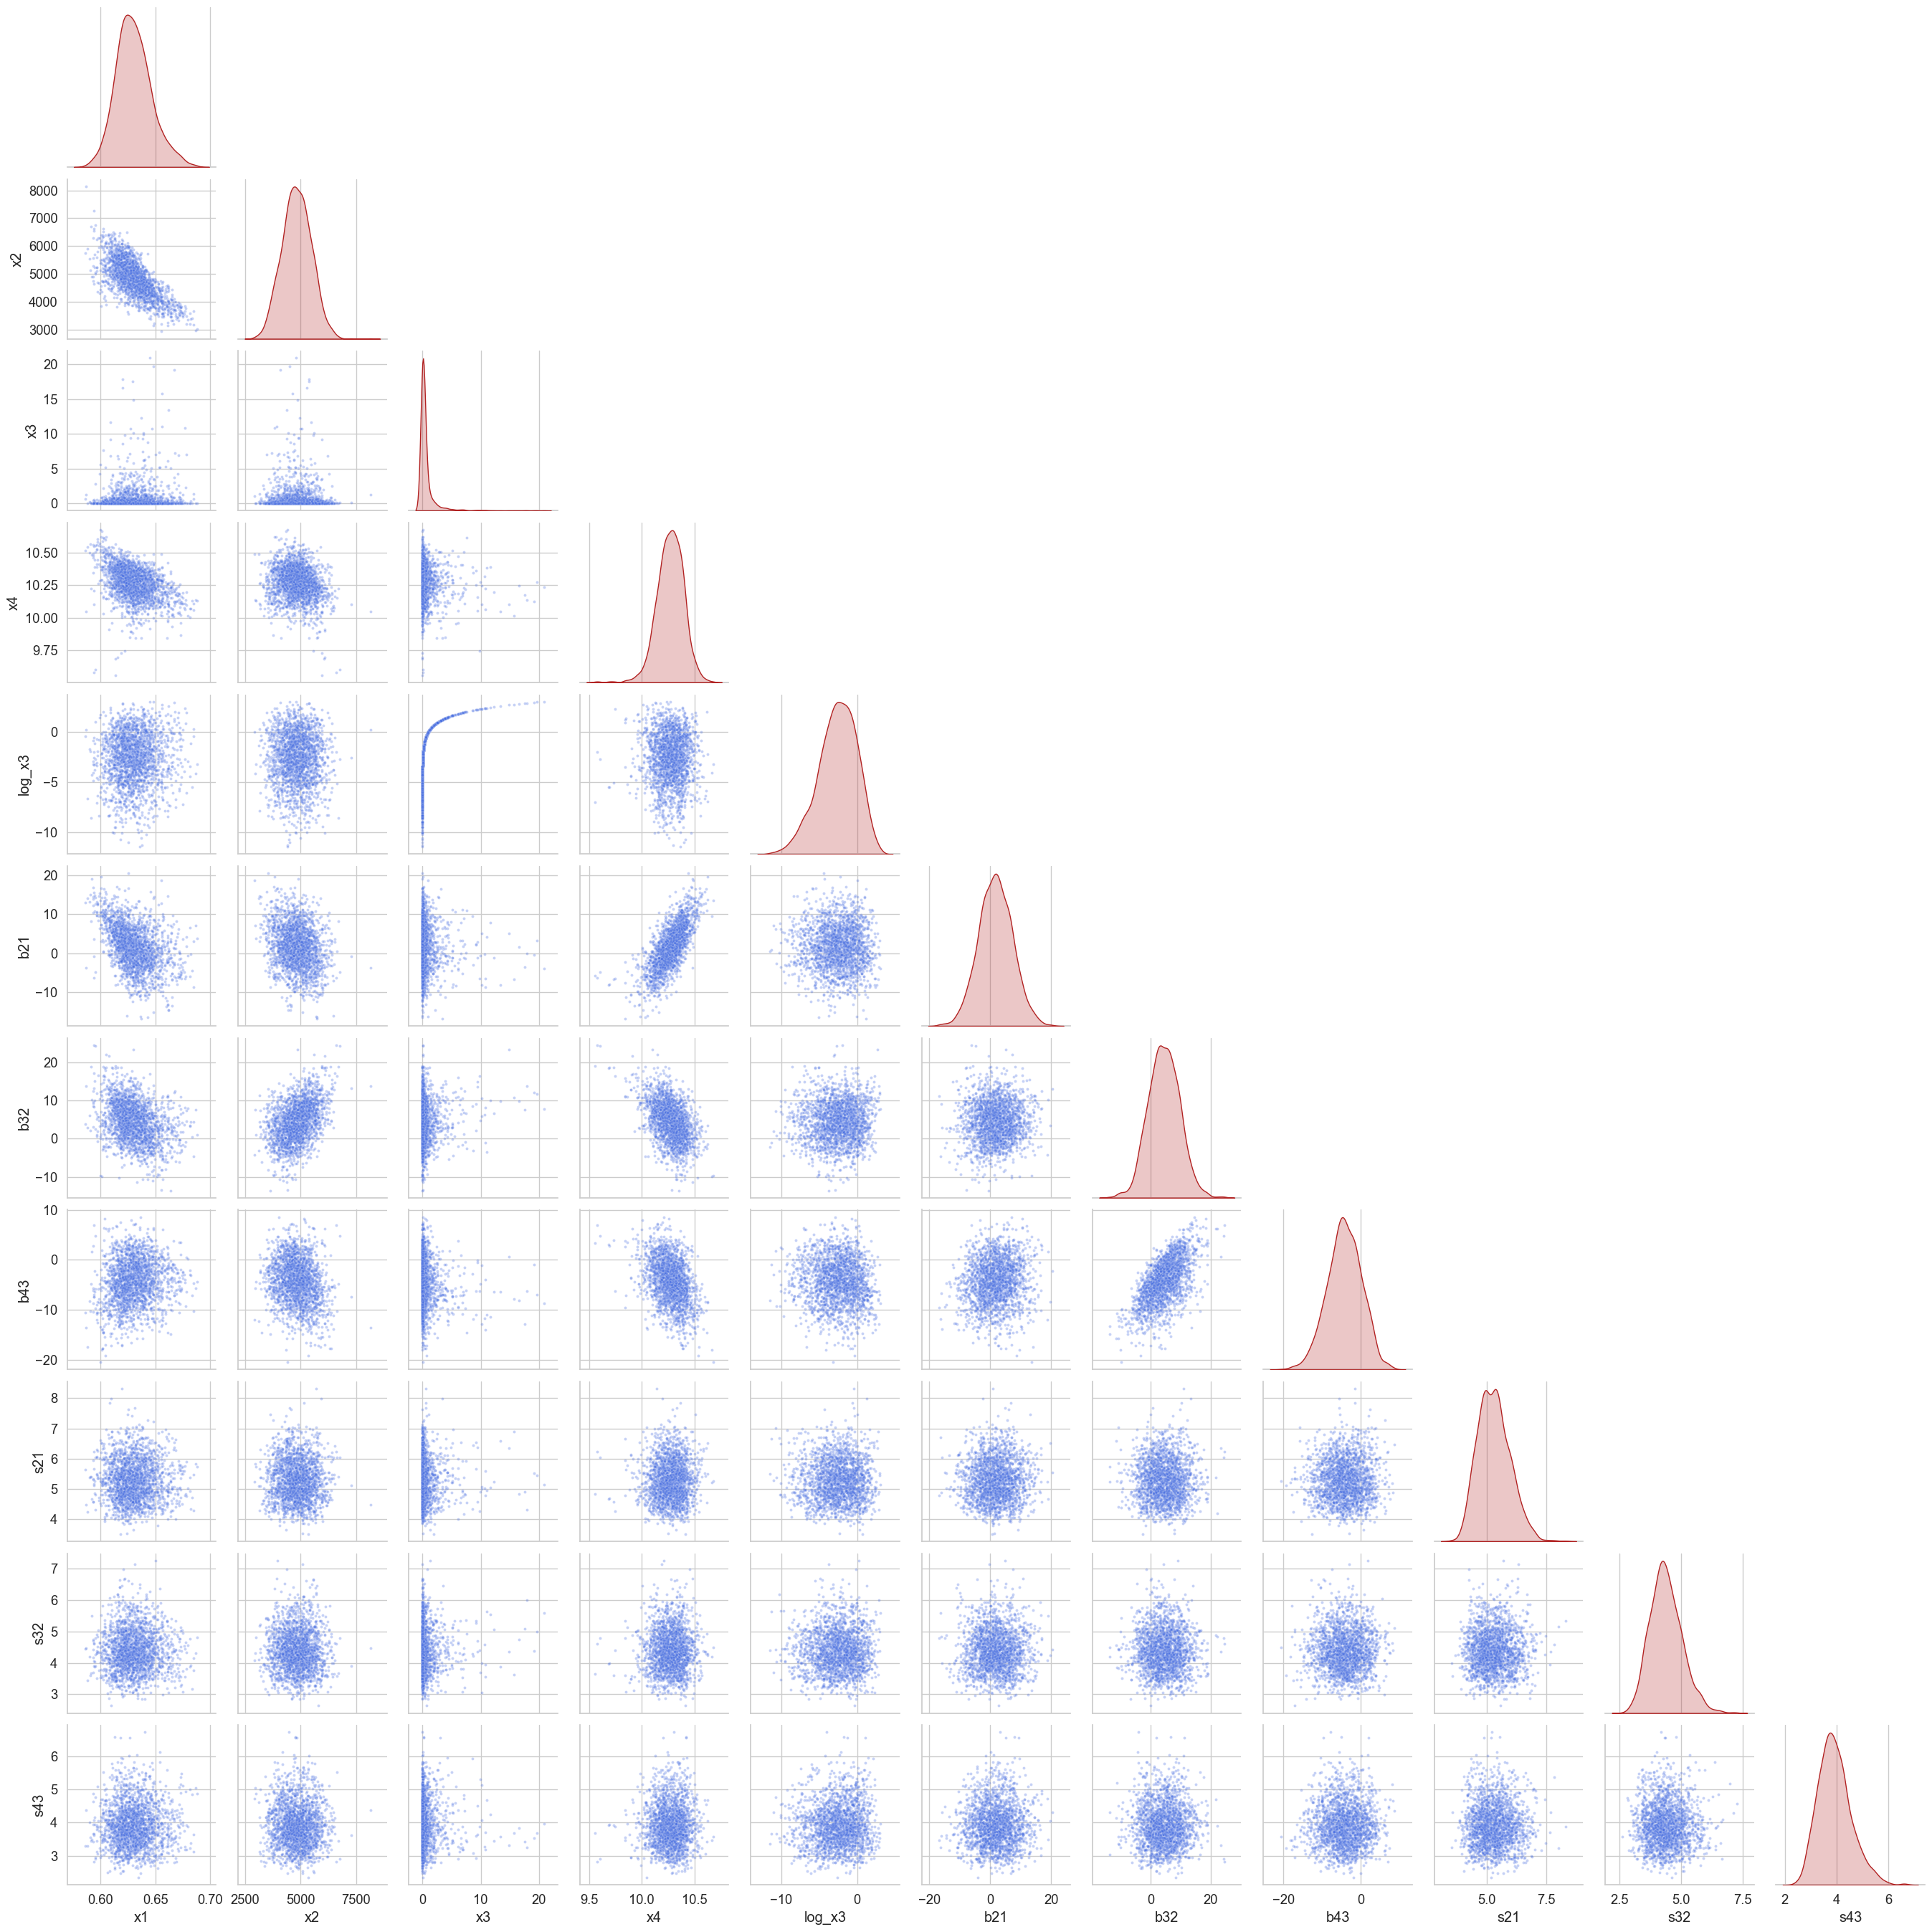

In [759]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="kde",
    diag_kws=dict(fill=True, color="firebrick"),
    plot_kws=dict(s=8, alpha=0.3, color="royalblue")
)
plt.show()


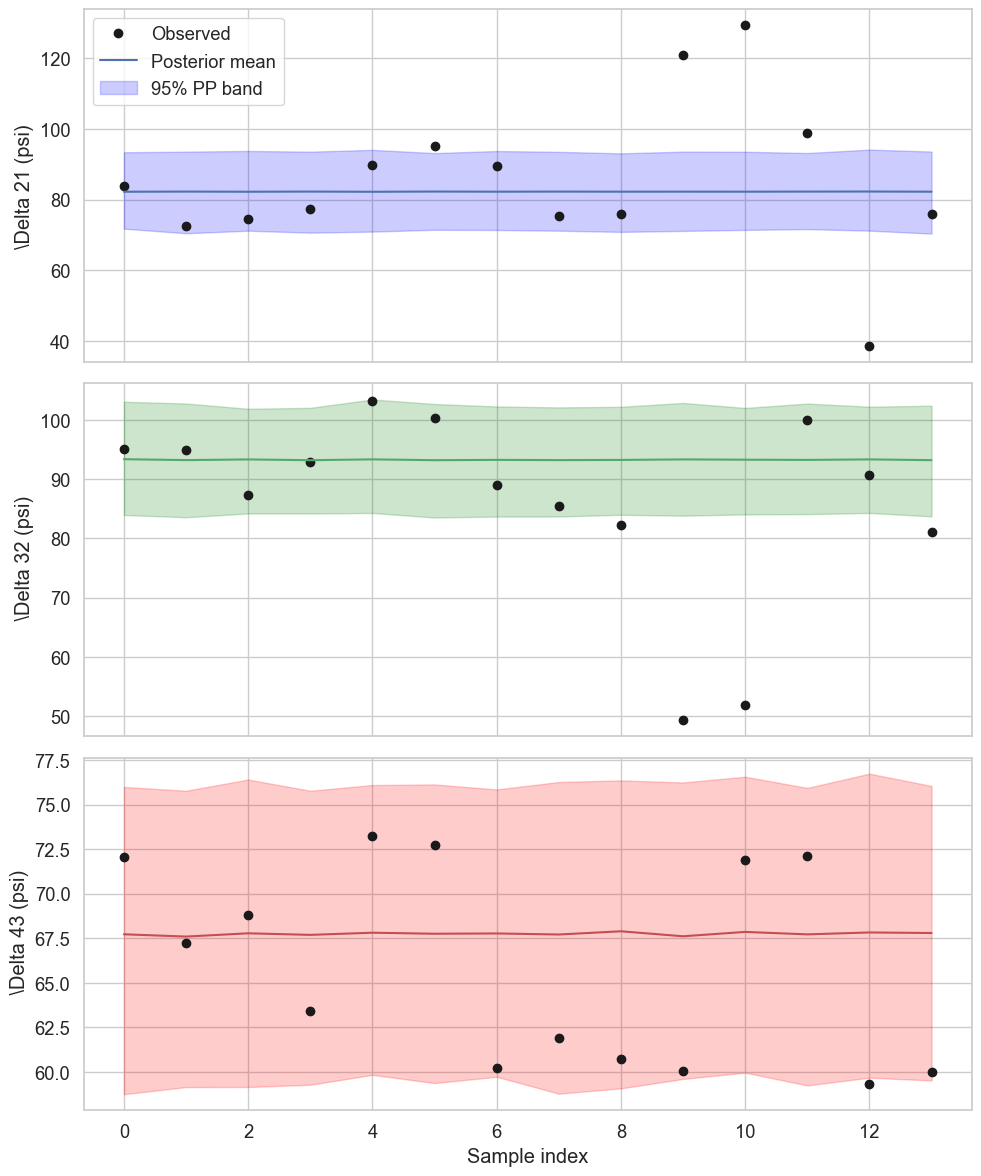

In [760]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------------
# Extract posterior samples
# -----------------------------
x1_s  = df["x1"].values
x2_s  = df["x2"].values * 10.0        # reverse earlier division
x3_s  = df["x3"].values
x4_s  = df["x4"].values

b21_s = df["b21"].values
b32_s = df["b32"].values
b43_s = df["b43"].values

s21_s = df["s21"].values
s32_s = df["s32"].values
s43_s = df["s43"].values

nsamp = len(df)

# ---------------------------------------------
# Compute posterior predictive for each sample
# ---------------------------------------------
def predict_deltas(x1, x2, x3, x4, F):
    f1 = gp_flow_maps(x1, x2, x3, x4, F[:,0]) / 6894.76
    f2 = gp_flow_maps(x1, x2, x3, x4, F[:,1]) / 6894.76
    f3 = gp_flow_maps(x1, x2, x3, x4, F[:,2]) / 6894.76
    f4 = gp_flow_maps(x1, x2, x3, x4, F[:,3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3
    return d21, d32, d43

# Storage
m21_all = []
m32_all = []
m43_all = []

y21_all = []
y32_all = []
y43_all = []

for i in range(nsamp):
    d21, d32, d43 = predict_deltas(
        x1_s[i], x2_s[i]/10.0, x3_s[i], x4_s[i], F
    )

    # latent means
    m21 = d21 + b21_s[i]
    m32 = d32 + b32_s[i]
    m43 = d43 + b43_s[i]

    # noisy posterior predictive
    y21 = m21 + np.random.normal(0, s21_s[i], size=len(m21))
    y32 = m32 + np.random.normal(0, s32_s[i], size=len(m32))
    y43 = m43 + np.random.normal(0, s43_s[i], size=len(m43))

    m21_all.append(m21)
    m32_all.append(m32)
    m43_all.append(m43)

    y21_all.append(y21)
    y32_all.append(y32)
    y43_all.append(y43)

# Convert to arrays (nsamp, N)
m21_all = np.vstack(m21_all)
m32_all = np.vstack(m32_all)
m43_all = np.vstack(m43_all)

y21_all = np.vstack(y21_all)
y32_all = np.vstack(y32_all)
y43_all = np.vstack(y43_all)

# ---------------------------------------------
# Compute posterior predictive summaries
# ---------------------------------------------
def summarise(arr):
    return (
        np.mean(arr, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )

m21_mean, m21_lo, m21_hi = summarise(m21_all)
m32_mean, m32_lo, m32_hi = summarise(m32_all)
m43_mean, m43_lo, m43_hi = summarise(m43_all)

y21_mean, y21_lo, y21_hi = summarise(y21_all)
y32_mean, y32_lo, y32_hi = summarise(y32_all)
y43_mean, y43_lo, y43_hi = summarise(y43_all)

# Observed
d21_obs = D[:,0]
d32_obs = D[:,1]
d43_obs = D[:,2]

# ---------------------------------------------
# Plot posterior predictive bands
# ---------------------------------------------
x = np.arange(len(F))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Δ21
ax = axes[0]
ax.plot(x, d21_obs, "ko", label="Observed")
ax.plot(x, m21_mean, "b-", label="Posterior mean")
ax.fill_between(x, y21_lo, y21_hi, color="blue", alpha=0.2, label="95% PP band")
ax.set_ylabel("\Delta 21 (psi)")
ax.legend()

# Δ32
ax = axes[1]
ax.plot(x, d32_obs, "ko")
ax.plot(x, m32_mean, "g-")
ax.fill_between(x, y32_lo, y32_hi, color="green", alpha=0.2)
ax.set_ylabel(" \Delta 32 (psi)")

# Δ43
ax = axes[2]
ax.plot(x, d43_obs, "ko")
ax.plot(x, m43_mean, "r-")
ax.fill_between(x, y43_lo, y43_hi, color="red", alpha=0.2)
ax.set_ylabel(" \Delta 43 (psi)")
ax.set_xlabel("Sample index")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


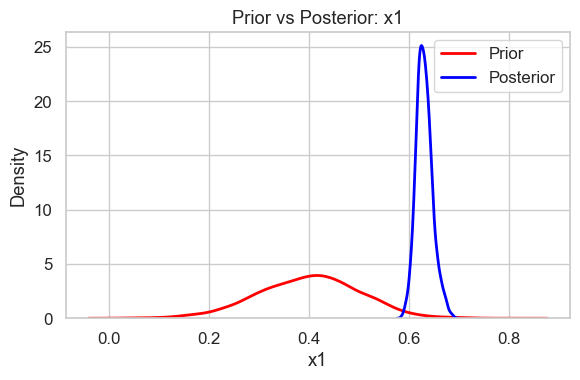

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


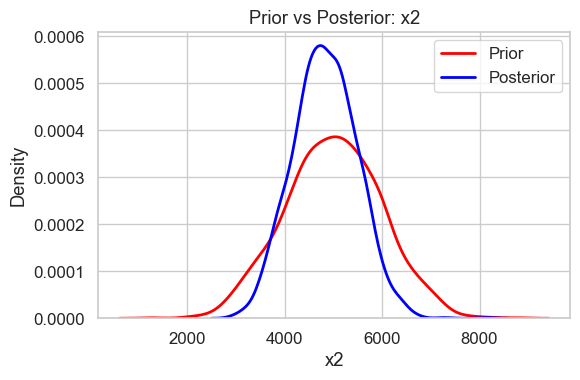

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


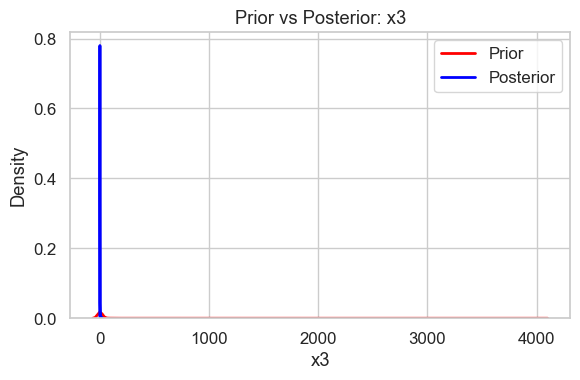

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


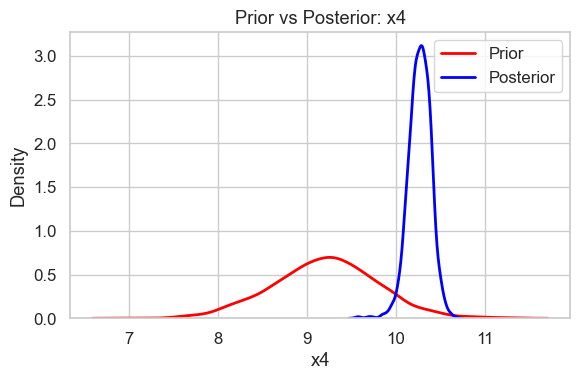

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


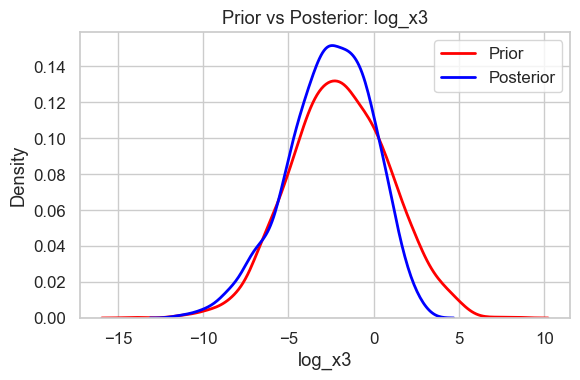

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


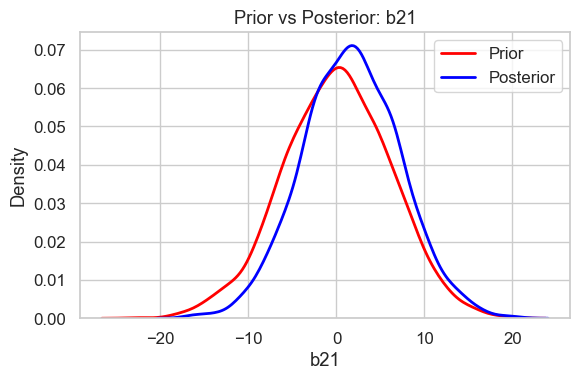

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


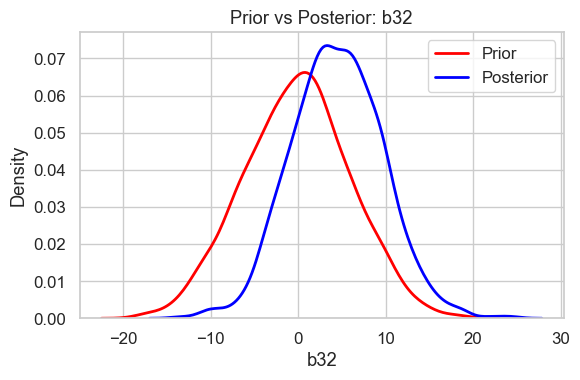

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


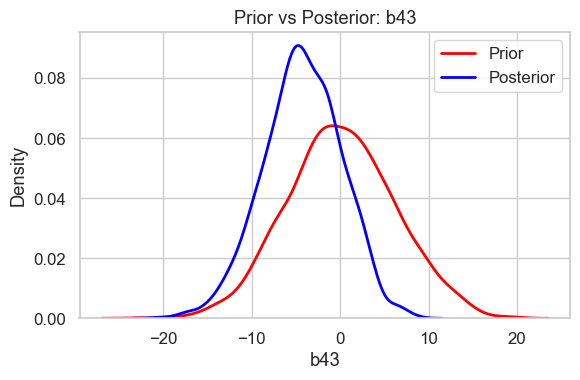

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


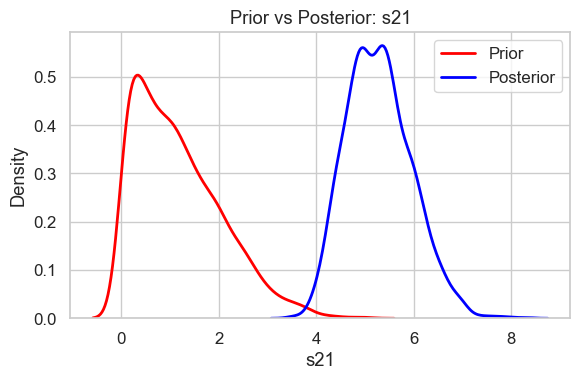

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


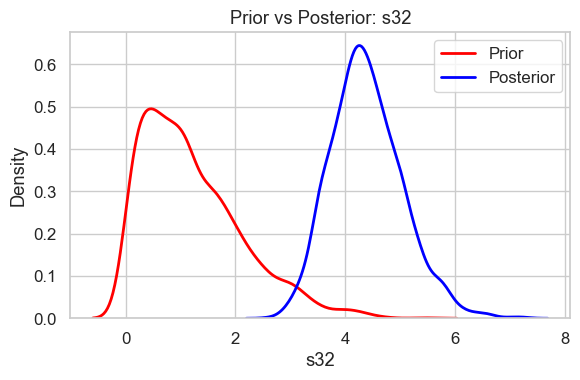

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


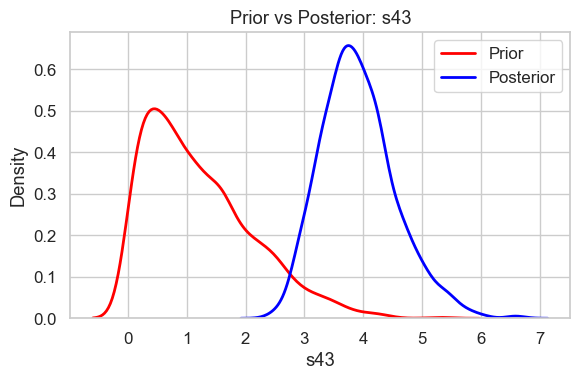

In [763]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

params = ["x1", "x2", "x3", "x4", "log_x3", "b21", "b32", "b43", "s21", "s32", "s43"]

for param in params:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df_prior[param], label="Prior", color="red", lw=2)
    sns.kdeplot(df[param],       label="Posterior", color="blue", lw=2)
    plt.title(f"Prior vs Posterior: {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [764]:
df.to_csv("posterior_samples_All_3.csv", index=False)
df_prior.to_csv("prior_samples_All_3.csv", index=False)

print("Saved posterior_samples.csv and prior_samples.csv")

Saved posterior_samples.csv and prior_samples.csv


## Experiment with different experiments

## Here we will have to narrow the bias priors so things dont get uddled up

## First with just Delta 21

In [830]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

# Physical bounds (used in transforms)
x_lb = jnp.array([0.34, 1e3, 1e-3, 1e-2])
x_ub = jnp.array([0.9,  1e4, 10.0, 10.0])


def model_calibrate_diffs(F, D):
    """
    Bayesian calibration using Δ12 (F2 - F1) only.

    F : (N, 4) array of flow rates
    D : (N, 3) array of measured pressure differences in psi
        D[:, 0] is Δ12.
    """

    # -------- PRIORS ON x1..x4 (TRANSFORMED SPACE) --------
    #x1 = numpyro.sample("x1", dist.Normal(0.4*100, 0.3*100))
    x2 = numpyro.sample("x2", dist.Normal(5e4, 1e4))
    z3 = numpyro.sample("z3", dist.Normal(-1., 2.))# -4, 2
    #z4 = numpyro.sample("z4", dist.Normal(2.2, 1))
    

    x3 = jnp.exp(z3)
    
    u = numpyro.sample("u", dist.Normal(0., 1.))   # along ridge
    v = numpyro.sample("v", dist.Normal(0., 1.))   # across ridge
    x1 = 100*(0.4 + 0.1 * u)
    x4 = 9.2 + 0.5 * u + 0.3 * v   # a = slope of x4 vs x1 you see in scatter
    #x4 = z4*x1/10. # 9.9 previosuly 

    # -------- GP PREDICTIONS (Δ12 ONLY) --------
    f1_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76  # psi
    f2_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76  # psi
    #f3_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76  # psi
    #f4_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76  # psi
    
    d21_pred = f2_pres_pred - f1_pres_pred
    #d32_pred = f3_pres_pred - f2_pres_pred
    #d43_pred = f4_pres_pred - f3_pres_pred
    
    
    if D is not None:
                
        d21_obs  = D[:, 0]
        d32_obs  = D[:, 1]
        d43_obs  = D[:, 2]
    else:
        d21_obs  = None
        d32_obs  = None
        d43_obs  = None

    # --------- BIAS TERMS ---------
    b21 = numpyro.sample("b21", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)
    #b32 = numpyro.sample("b32", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    #b43 = numpyro.sample("b43", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)

    m21 = d21_pred + b21
    #m32 = d32_pred + b32
    #m43 = d43_pred + b43

    # expose latent means as deterministic nodes
    numpyro.deterministic("m21", m21)
    #numpyro.deterministic("m32", m32)
    #numpyro.deterministic("m43", m43)

    # -------- NOISE MODEL (GAUSSIAN) --------
    s21 = numpyro.sample("s21", dist.HalfNormal(1.5))
    #s32 = numpyro.sample("s32", dist.HalfNormal(1.5))
    #s43 = numpyro.sample("s43", dist.HalfNormal(1.5))

    # Likelihood for Delta12, Delta23
    numpyro.sample("y21", dist.Normal(loc=m21, scale=s21), obs=d21_obs)
    #numpyro.sample("y32", dist.Normal(loc=m32, scale=s32), obs=d32_obs)
    #numpyro.sample("y43", dist.Normal(loc=m43, scale=s43), obs=d43_obs)


In [831]:
from numpyro.infer import Predictive
import jax.random as jr

# draw samples from the prior
prior_pred = Predictive(model_calibrate_diffs, num_samples=2000)
prior_samples = prior_pred(jr.PRNGKey(0), F, None)

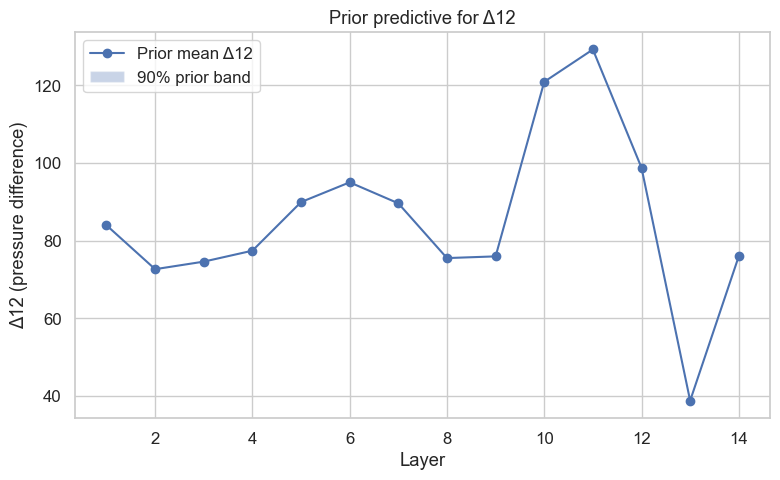

In [832]:
import matplotlib.pyplot as plt

# summary across prior samples
mean_prior = y21_prior.mean(axis=0)
p5_prior   = np.percentile(y21_prior, 5, axis=0)
p95_prior  = np.percentile(y21_prior, 95, axis=0)

layers = np.arange(1, y21_prior.shape[1] + 1)

plt.figure(figsize=(8,5))
plt.plot(layers, mean_prior, label="Prior mean Δ12", marker="o")
plt.fill_between(layers, p5_prior, p95_prior, alpha=0.3, label="90% prior band")

plt.xlabel("Layer")
plt.ylabel("Δ12 (pressure difference)")
plt.title("Prior predictive for Δ12")
plt.legend()
plt.tight_layout()
plt.show()


In [833]:
def run_nuts_calibration(
    F, D,
    seed=77, warmup=700, samples=1300, chains=2,
    target_accept=0.70, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F[:8, :], D[:8, :])
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D)
samples = mcmc.get_samples()


sample: 100%|██████████████████████████████████████████████████████████| 2000/2000 [02:16<00:00, 14.61it/s, 9 steps of size 1.30e-01. acc. prob=0.76]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       b21     -0.00      1.01     -0.01     -1.62      1.59    368.33      1.01
       s21      5.27      0.69      5.23      4.14      6.36    189.61      1.01
         u      2.19      0.20      2.17      1.86      2.53     69.36      1.04
         v      0.04      1.05      0.03     -1.75      1.61    288.42      1.01
        x2  53781.76  11120.04  54143.33  35120.71  73010.18     37.71      1.06
        z3     -0.98      1.91     -0.92     -4.19      2.04   1678.21      1.00

Number of divergences: 74


In [834]:
import numpy as np
import pandas as pd
import jax.numpy as jnp

# Get raw samples from MCMC
samples = mcmc.get_samples()

# Reconstruct physical parameters
u_samples   = samples["u"]
v_samples   = samples["v"]
x2_samples  = samples["x2"]           # still in original scale
z3_samples  = samples["z3"]           # log(x3)
b21_samples = samples["b21"]
s21_samples = samples["s21"]

# Transformations to physical space
x1_samples  = 0.4 + 0.1 * u_samples      # matches model: x1 = 100*(0.4 + 0.1*u)
x2_phys     = x2_samples / 10.0                    # if GP used x2/10.
x3_samples  = jnp.exp(z3_samples)                  # x3 = exp(z3)
x4_samples  = 9.2 + 0.5 * u_samples + 0.3 * v_samples  # 9. + 1. * 0.5 * u + 0.3 * v 

# Convert to NumPy for pandas
x1_np  = np.asarray(x1_samples)
x2_np  = np.asarray(x2_phys)
x3_np  = np.asarray(x3_samples)
x4_np  = np.asarray(x4_samples)
u_np   = np.asarray(u_samples)
v_np   = np.asarray(v_samples)
z3_np  = np.asarray(z3_samples)
b21_np = np.asarray(b21_samples)
s21_np = np.asarray(s21_samples)


# Build DataFrame
df = pd.DataFrame({
    "x1":  x1_np,
    "x2":  x2_np,
    "x3": x3_np,
    "x4":  x4_np,
    "log_x3": z3_np,
    "b21": b21_np,
    "s21": s21_np,
})

# Optional: quick peek
print(df.head())


         x1           x2        x3         x4    log_x3       b21       s21
0  0.611490  6369.125977  0.093131  10.600452 -2.373751 -0.966904  4.044572
1  0.634986  4731.000977  0.738546  10.385028 -0.303072 -1.672315  7.842528
2  0.630927  5203.985352  0.511352  10.452270 -0.670697 -1.433458  6.188964
3  0.599212  6371.122070  1.221079  10.150568  0.199735  0.808909  4.481671
4  0.595591  6840.417969  2.513418  10.022891  0.921644  0.931268  4.264405


In [835]:
num_prior = 2000  # or whatever

prior_pred = Predictive(model_calibrate_diffs, num_samples=num_prior)
# Note: pass only F; D will default to None inside the model
prior_samples = prior_samples

# ----- 2) Reconstruct physical parameters from prior -----
u_prior   = prior_samples["u"]
v_prior   = prior_samples["v"]
x2_prior  = prior_samples["x2"]
z3_prior  = prior_samples["z3"]
b21_prior = prior_samples["b21"]
s21_prior = prior_samples["s21"]

# Same transformations as posterior code
x1_prior  = 0.4 + 0.1 * u_prior                # GP-scale x1/100
x2_prior_phys = x2_prior / 10.0                # GP used x2/10
x3_prior  = jnp.exp(z3_prior)
x4_prior  = 9.2 + 0.5 * u_prior + 0.3 * v_prior

# Convert to NumPy
x1_p  = np.asarray(x1_prior)
x2_p  = np.asarray(x2_prior_phys)
x3_p  = np.asarray(x3_prior)
x4_p  = np.asarray(x4_prior)
z3_p  = np.asarray(z3_prior)
b21_p = np.asarray(b21_prior)
s21_p = np.asarray(s21_prior)

# ----- 3) Build prior DataFrame -----
df_prior = pd.DataFrame({
    "x1":      x1_p,
    "x2":      x2_p,
    "x3":      x3_p,
    "x4":      x4_p,
    "log_x3":  z3_p,
    "b21":     b21_p,
    "s21":     s21_p,
})

print(df_prior.head())

         x1           x2        x3        x4    log_x3       b21       s21
0  0.457573  4957.405273  0.630753  9.137889 -0.460841  0.384647  1.292406
1  0.448919  5979.233887  0.029810  9.329538 -3.512919 -0.020355  1.047144
2  0.249714  5252.323242  2.335710  8.274053  0.848316 -0.175773  1.918535
3  0.438283  4336.837891  0.017581  9.670922 -4.040934  1.230969  0.291747
4  0.335213  5519.859375  0.153402  9.217848 -1.874691  0.007216  1.698671


In [836]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

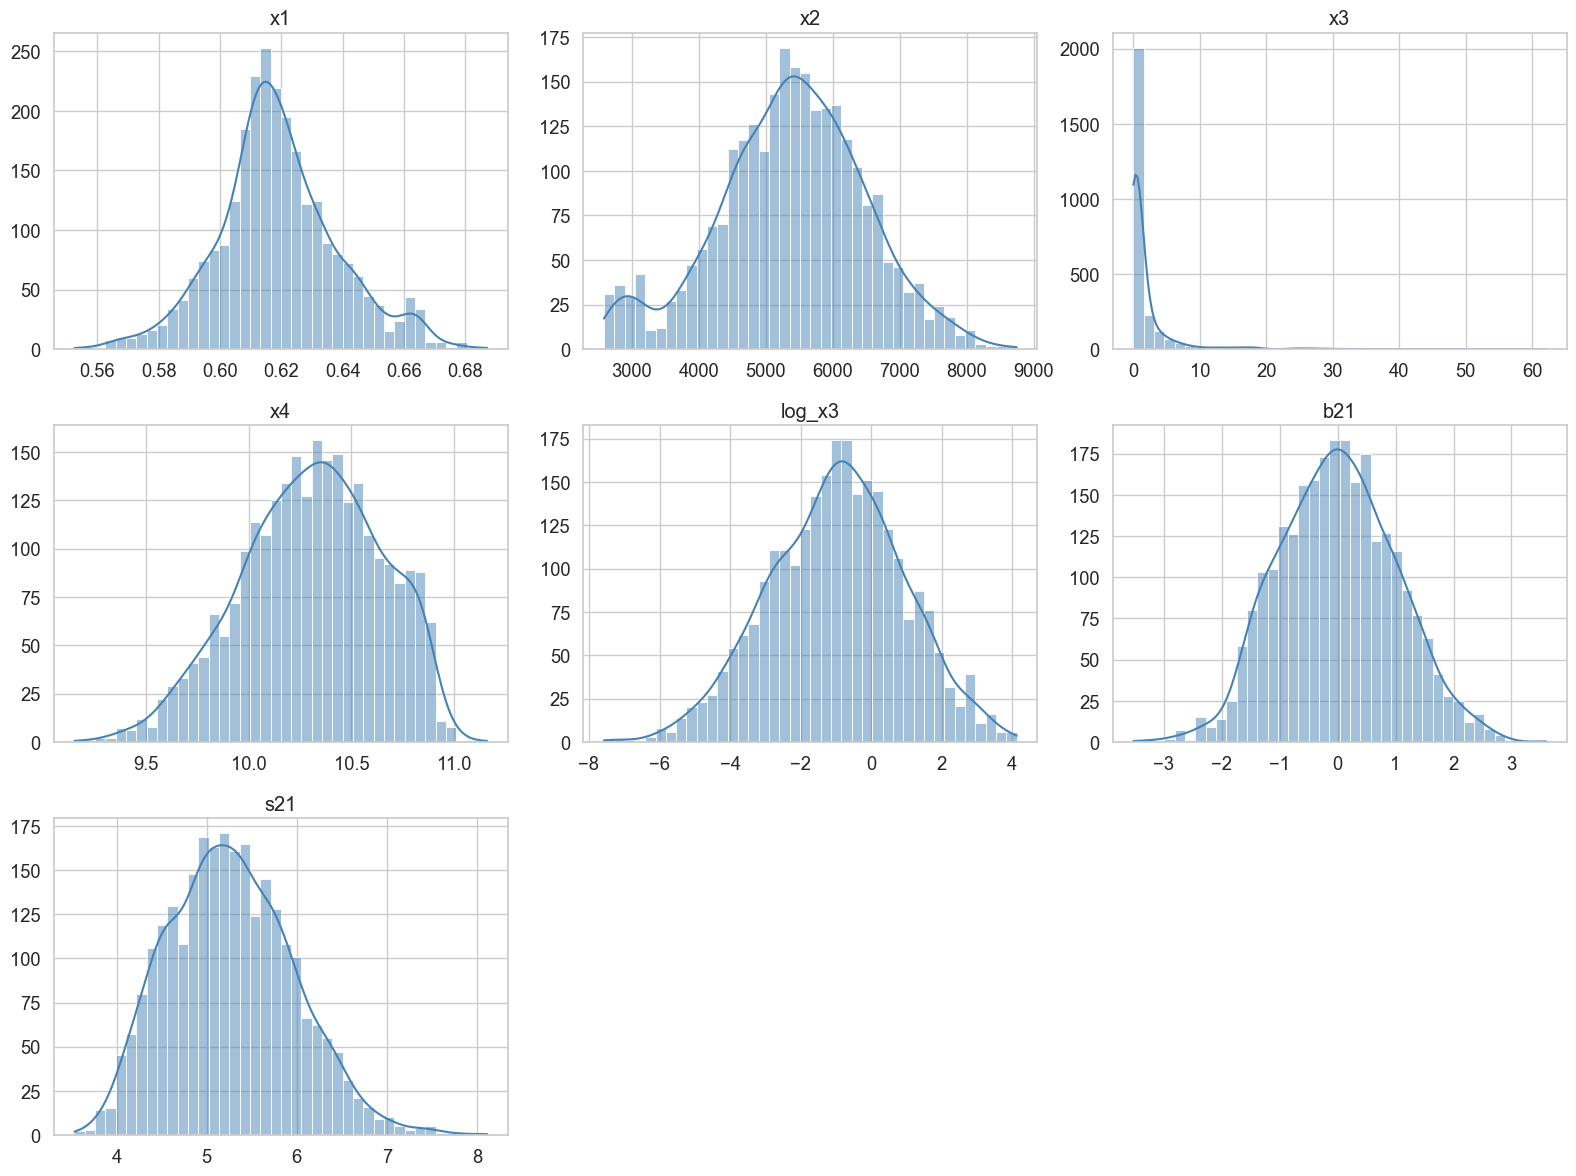

In [837]:
params = df.columns
n = len(params)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for ax, param in zip(axes, params):
    sns.histplot(df[param], bins=40, kde=True, color="steelblue", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Turn off any unused axes
for j in range(len(params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

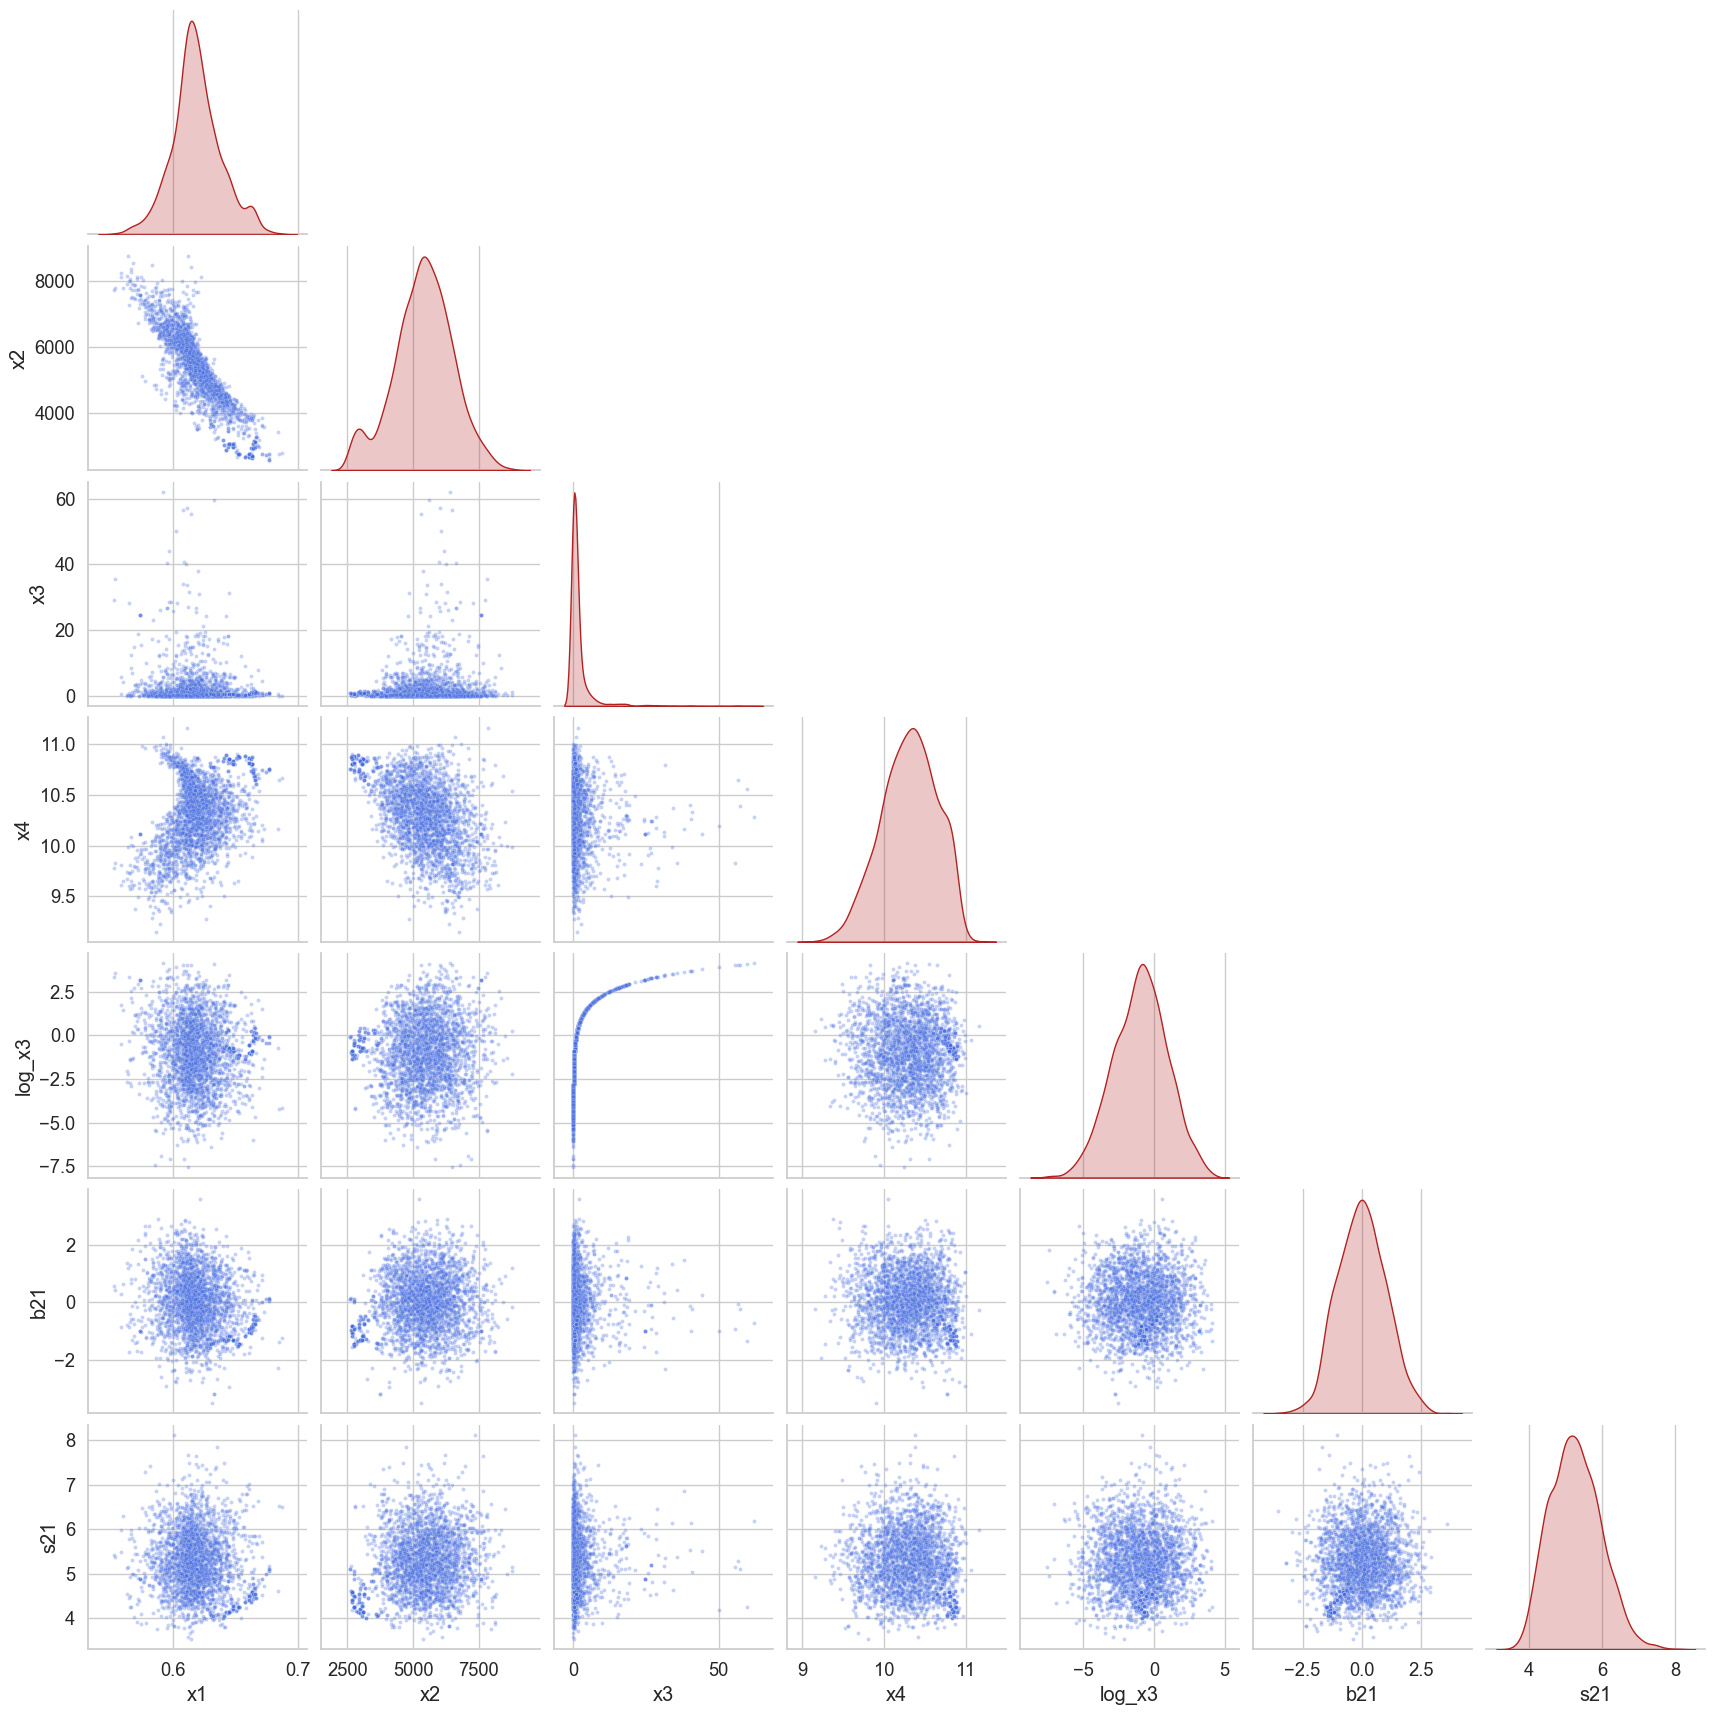

In [838]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="kde",
    diag_kws=dict(fill=True, color="firebrick"),
    plot_kws=dict(s=8, alpha=0.3, color="royalblue")
)
plt.show()


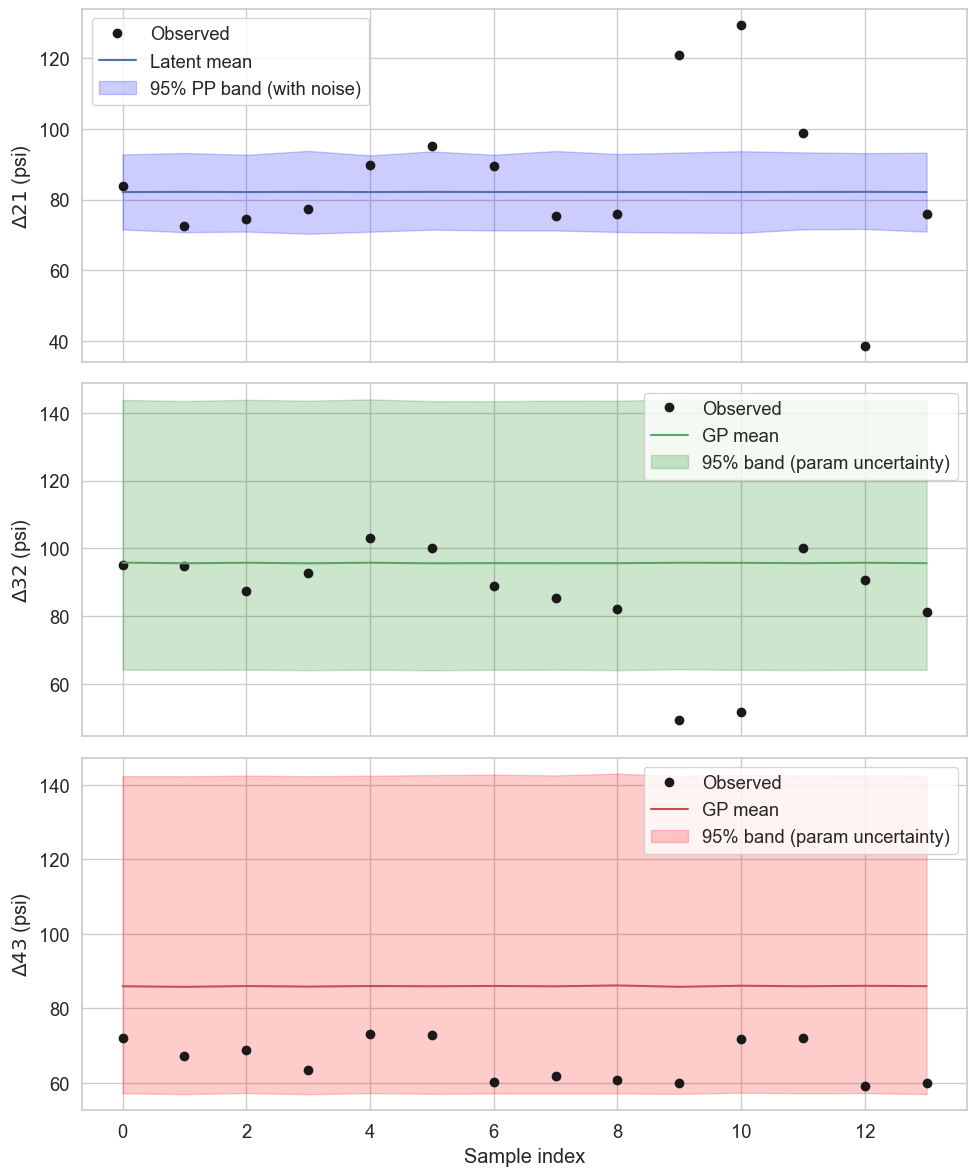

In [839]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------------
# Extract posterior samples
# -----------------------------
x1_s  = df["x1"].values             # GP-scale x1 (as you stored it)
x2_s  = df["x2"].values * 10.0      # reverse earlier division, back to model scale if needed
x3_s  = df["x3"].values
x4_s  = df["x4"].values

b21_s = df["b21"].values
s21_s = df["s21"].values

nsamp = len(df)

# ---------------------------------------------
# Compute posterior predictive for each sample
# ---------------------------------------------
def predict_deltas(x1, x2, x3, x4, F):
    # Adjust these calls if your gp_flow_maps expects scaled x1/x2
    f1 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3
    return d21, d32, d43

# Storage
m21_all = []
m32_all = []
m43_all = []

y21_all = []

for i in range(nsamp):
    d21, d32, d43 = predict_deltas(
        x1_s[i], x2_s[i] / 10.0, x3_s[i], x4_s[i], F
    )

    # latent mean for Δ21 (has bias)
    m21 = d21 + b21_s[i]

    # for Δ32 and Δ43: mean predictions only from GP (no bias)
    m32 = d32
    m43 = d43

    # noisy posterior predictive ONLY for Δ21
    y21 = m21 + np.random.normal(0, s21_s[i], size=len(m21))

    m21_all.append(m21)
    m32_all.append(m32)
    m43_all.append(m43)
    y21_all.append(y21)

# Convert to arrays (nsamp, N)
m21_all = np.vstack(m21_all)
m32_all = np.vstack(m32_all)
m43_all = np.vstack(m43_all)
y21_all = np.vstack(y21_all)

# ---------------------------------------------
# Compute posterior predictive summaries
# ---------------------------------------------
def summarise(arr):
    return (
        np.mean(arr, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )

# Δ21: we have both latent mean and noisy predictive
m21_mean, m21_lo, m21_hi = summarise(m21_all)
y21_mean, y21_lo, y21_hi = summarise(y21_all)

# Δ32, Δ43: only parameter-uncertainty bands from m32, m43
m32_mean, m32_lo, m32_hi = summarise(m32_all)
m43_mean, m43_lo, m43_hi = summarise(m43_all)

# Observed
d21_obs = D[:, 0]
d32_obs = D[:, 1]
d43_obs = D[:, 2]

# ---------------------------------------------
# Plot posterior predictive bands
# ---------------------------------------------
x = np.arange(len(F))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Δ21: full posterior predictive
ax = axes[0]
ax.plot(x, d21_obs, "ko", label="Observed")
ax.plot(x, m21_mean, "b-", label="Latent mean")
ax.fill_between(x, y21_lo, y21_hi, color="blue", alpha=0.2, label="95% PP band (with noise)")
ax.set_ylabel(r"$\Delta 21$ (psi)")
ax.legend()

# Δ32: GP-only (no noise calibration)
ax = axes[1]
ax.plot(x, d32_obs, "ko", label="Observed")
ax.plot(x, m32_mean, "g-", label="GP mean")
ax.fill_between(x, m32_lo, m32_hi, color="green", alpha=0.2, label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 32$ (psi)")
ax.legend()

# Δ43: GP-only (no noise calibration)
ax = axes[2]
ax.plot(x, d43_obs, "ko", label="Observed")
ax.plot(x, m43_mean, "r-", label="GP mean")
ax.fill_between(x, m43_lo, m43_hi, color="red", alpha=0.2, label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 43$ (psi)")
ax.set_xlabel("Sample index")
ax.legend()

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


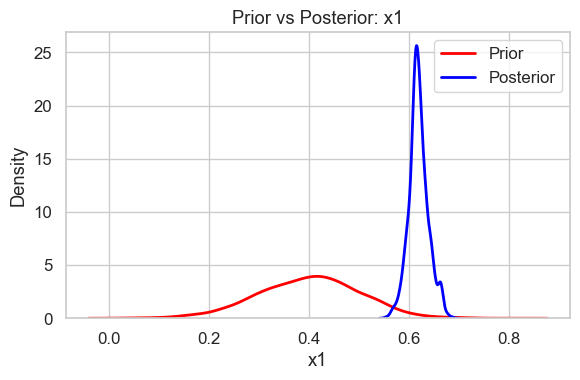

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


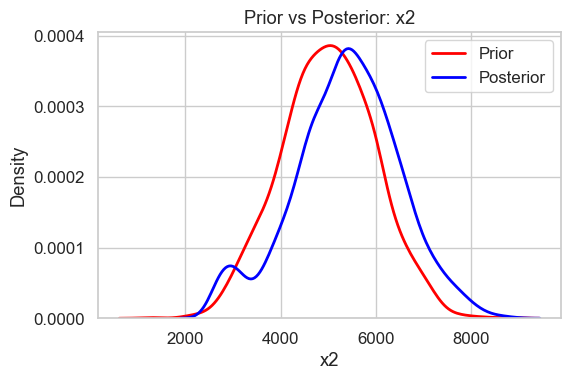

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


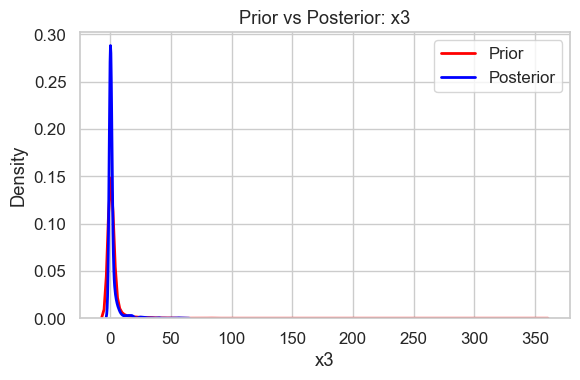

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


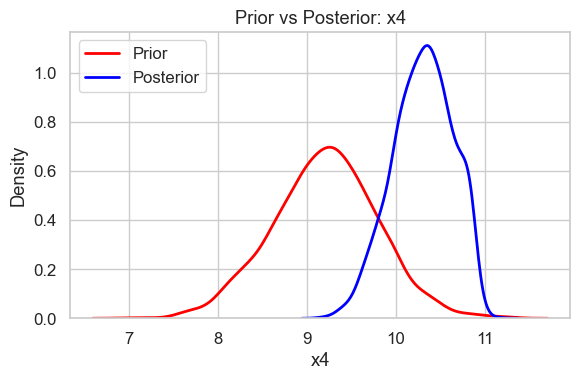

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


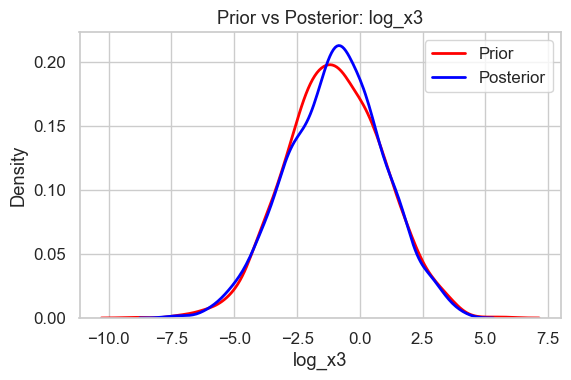

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


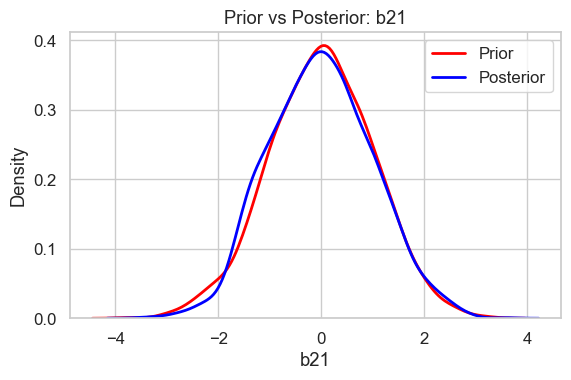

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


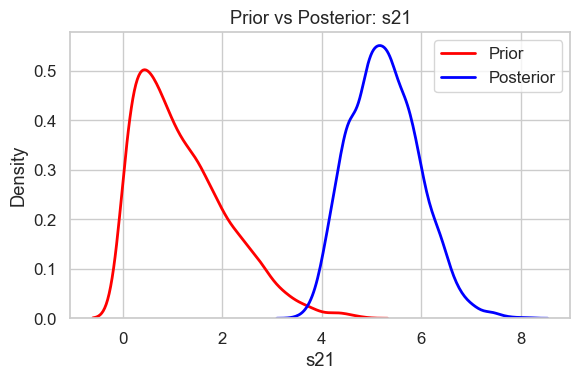

In [840]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

params = ["x1", "x2", "x3", "x4", "log_x3", "b21", "s21",]

for param in params:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df_prior[param], label="Prior", color="red", lw=2)
    sns.kdeplot(df[param],       label="Posterior", color="blue", lw=2)
    plt.title(f"Prior vs Posterior: {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [841]:
df.to_csv("posterior_samples_delta21.csv", index=False)
df_prior.to_csv("prior_samples_delta21.csv", index=False)

print("Saved posterior_samples.csv and prior_samples.csv")

Saved posterior_samples.csv and prior_samples.csv



## NExt with delta 43


In [842]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

# Physical bounds (used in transforms)
x_lb = jnp.array([0.34, 1e3, 1e-3, 1e-2])
x_ub = jnp.array([0.9,  1e4, 10.0, 10.0])


def model_calibrate_diffs(F, D):
    """
    Bayesian calibration using Δ12 (F2 - F1) only.

    F : (N, 4) array of flow rates
    D : (N, 3) array of measured pressure differences in psi
        D[:, 0] is Δ12.
    """

    # -------- PRIORS ON x1..x4 (TRANSFORMED SPACE) --------
    #x1 = numpyro.sample("x1", dist.Normal(0.4*100, 0.3*100))
    x2 = numpyro.sample("x2", dist.Normal(5e4, 1e4))
    z3 = numpyro.sample("z3", dist.Normal(-1., 2.))# -4, 2
    #z4 = numpyro.sample("z4", dist.Normal(2.2, 1))
    

    x3 = jnp.exp(z3)
    
    u = numpyro.sample("u", dist.Normal(0., 1.))   # along ridge
    v = numpyro.sample("v", dist.Normal(0., 1.))   # across ridge
    x1 = 100*(0.4 + 0.1 * u)
    x4 = 9.2 + 0.5 * u + 0.3 * v   # a = slope of x4 vs x1 you see in scatter
    #x4 = z4*x1/10. # 9.9 previosuly 

    # -------- GP PREDICTIONS (Δ12 ONLY) --------
    #f1_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 0]) / 6894.76  # psi
    #f2_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 1]) / 6894.76  # psi
    f3_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 2]) / 6894.76  # psi
    f4_pres_pred = gp_flow_maps(x1/100., x2/10., x3, x4, F[:, 3]) / 6894.76  # psi
    
    #d21_pred = f2_pres_pred - f1_pres_pred
    #d32_pred = f3_pres_pred - f2_pres_pred
    d43_pred = f4_pres_pred - f3_pres_pred
    
    
    if D is not None:
                
        d21_obs  = D[:, 0]
        d32_obs  = D[:, 1]
        d43_obs  = D[:, 2]
    else:
        d21_obs  = None
        d32_obs  = None
        d43_obs  = None

    # --------- BIAS TERMS ---------
    #b21 = numpyro.sample("b21", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    #b32 = numpyro.sample("b32", dist.Normal(0.0, 6.)) # dist.Normal(0.0, 4.)
    b43 = numpyro.sample("b43", dist.Normal(0.0, 1.)) # dist.Normal(0.0, 4.)

    #m21 = d21_pred + b21
    #m32 = d32_pred + b32
    m43 = d43_pred + b43

    # expose latent means as deterministic nodes
    #numpyro.deterministic("m21", m21)
    #numpyro.deterministic("m32", m32)
    numpyro.deterministic("m43", m43)

    # -------- NOISE MODEL (GAUSSIAN) --------
    #s21 = numpyro.sample("s21", dist.HalfNormal(1.5))
    #s32 = numpyro.sample("s32", dist.HalfNormal(1.5))
    s43 = numpyro.sample("s43", dist.HalfNormal(1.5))

    # Likelihood for Delta12, Delta23
    #numpyro.sample("y21", dist.Normal(loc=m21, scale=s21), obs=d21_obs)
    #numpyro.sample("y32", dist.Normal(loc=m32, scale=s32), obs=d32_obs)
    numpyro.sample("y43", dist.Normal(loc=m43, scale=s43), obs=d43_obs)


In [843]:
from numpyro.infer import Predictive
import jax.random as jr

# draw samples from the prior
prior_pred = Predictive(model_calibrate_diffs, num_samples=2000)
prior_samples = prior_pred(jr.PRNGKey(0), F, None)

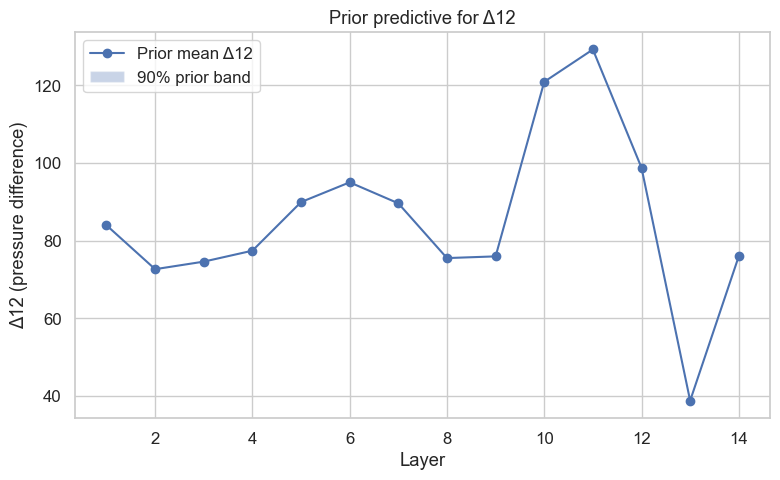

In [844]:
import matplotlib.pyplot as plt

# summary across prior samples
mean_prior = y21_prior.mean(axis=0)
p5_prior   = np.percentile(y21_prior, 5, axis=0)
p95_prior  = np.percentile(y21_prior, 95, axis=0)

layers = np.arange(1, y21_prior.shape[1] + 1)

plt.figure(figsize=(8,5))
plt.plot(layers, mean_prior, label="Prior mean Δ12", marker="o")
plt.fill_between(layers, p5_prior, p95_prior, alpha=0.3, label="90% prior band")

plt.xlabel("Layer")
plt.ylabel("Δ12 (pressure difference)")
plt.title("Prior predictive for Δ12")
plt.legend()
plt.tight_layout()
plt.show()


In [845]:
def run_nuts_calibration(
    F, D,
    seed=77, warmup=700, samples=1300, chains=2,
    target_accept=0.70, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F[:8, :], D[:8, :])
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D)
samples = mcmc.get_samples()


sample: 100%|████████████████████████████████████████████████████████| 2000/2000 [07:27<00:00,  4.47it/s, 127 steps of size 3.50e-02. acc. prob=0.79]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       b43      0.01      1.00     -0.00     -1.69      1.54   1769.84      1.00
       s43      3.91      0.67      3.82      2.78      4.94   1449.57      1.00
         u      2.00      0.28      2.00      1.57      2.46    719.91      1.00
         v      0.23      1.08      0.23     -1.53      1.95    916.88      1.00
        x2  54589.96  10272.76  55003.71  38458.03  71867.18    945.60      1.00
        z3     -0.84      2.00     -0.84     -3.90      2.72   1690.96      1.00

Number of divergences: 3


In [846]:
import numpy as np
import pandas as pd
import jax.numpy as jnp

# Get raw samples from MCMC
samples = mcmc.get_samples()

# Reconstruct physical parameters
u_samples   = samples["u"]
v_samples   = samples["v"]
x2_samples  = samples["x2"]           # still in original scale
z3_samples  = samples["z3"]           # log(x3)
b43_samples = samples["b43"]
s43_samples = samples["s43"]

# Transformations to physical space
x1_samples  = 0.4 + 0.1 * u_samples      # matches model: x1 = 100*(0.4 + 0.1*u)
x2_phys     = x2_samples / 10.0                    # if GP used x2/10.
x3_samples  = jnp.exp(z3_samples)                  # x3 = exp(z3)
x4_samples  = 9.2 + 0.5 * u_samples + 0.3 * v_samples  # 9. + 1. * 0.5 * u + 0.3 * v 

# Convert to NumPy for pandas
x1_np  = np.asarray(x1_samples)
x2_np  = np.asarray(x2_phys)
x3_np  = np.asarray(x3_samples)
x4_np  = np.asarray(x4_samples)
u_np   = np.asarray(u_samples)
v_np   = np.asarray(v_samples)
z3_np  = np.asarray(z3_samples)
b43_np = np.asarray(b43_samples)
s43_np = np.asarray(s43_samples)


# Build DataFrame
df = pd.DataFrame({
    "x1":  x1_np,
    "x2":  x2_np,
    "x3": x3_np,
    "x4":  x4_np,
    "log_x3": z3_np,
    "b43": b21_np,
    "s43": s21_np,
})

# Optional: quick peek
print(df.head())


         x1           x2        x3         x4    log_x3       b43       s43
0  0.654284  3240.066162  1.174436  10.262815  0.160788 -0.966904  4.044572
1  0.642719  5030.495605  0.108124   9.851028 -2.224473 -1.672315  7.842528
2  0.637801  5305.674805  0.266539  10.004463 -1.322233 -1.433458  6.188964
3  0.635357  5171.897461  2.113760   9.757738  0.748468  0.808909  4.481671
4  0.589834  7498.853027  0.074726   9.959558 -2.593934  0.931268  4.264405


In [847]:
num_prior = 2000  # or whatever

prior_pred = Predictive(model_calibrate_diffs, num_samples=num_prior)
# Note: pass only F; D will default to None inside the model
prior_samples = prior_samples

# ----- 2) Reconstruct physical parameters from prior -----
u_prior   = prior_samples["u"]
v_prior   = prior_samples["v"]
x2_prior  = prior_samples["x2"]
z3_prior  = prior_samples["z3"]
b43_prior = prior_samples["b43"]
s43_prior = prior_samples["s43"]

# Same transformations as posterior code
x1_prior  = 0.4 + 0.1 * u_prior                # GP-scale x1/100
x2_prior_phys = x2_prior / 10.0                # GP used x2/10
x3_prior  = jnp.exp(z3_prior)
x4_prior  = 9.2 + 0.5 * u_prior + 0.3 * v_prior

# Convert to NumPy
x1_p  = np.asarray(x1_prior)
x2_p  = np.asarray(x2_prior_phys)
x3_p  = np.asarray(x3_prior)
x4_p  = np.asarray(x4_prior)
z3_p  = np.asarray(z3_prior)
b43_p = np.asarray(b43_prior)
s43_p = np.asarray(s43_prior)

# ----- 3) Build prior DataFrame -----
df_prior = pd.DataFrame({
    "x1":      x1_p,
    "x2":      x2_p,
    "x3":      x3_p,
    "x4":      x4_p,
    "log_x3":  z3_p,
    "b43":     b43_p,
    "s43":     s43_p,
})

print(df_prior.head())

         x1           x2        x3        x4    log_x3       b43       s43
0  0.457573  4957.405273  0.630753  9.137889 -0.460841  0.384647  1.292406
1  0.448919  5979.233887  0.029810  9.329538 -3.512919 -0.020355  1.047144
2  0.249714  5252.323242  2.335710  8.274053  0.848316 -0.175773  1.918535
3  0.438283  4336.837891  0.017581  9.670922 -4.040934  1.230969  0.291747
4  0.335213  5519.859375  0.153402  9.217848 -1.874691  0.007216  1.698671


In [848]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

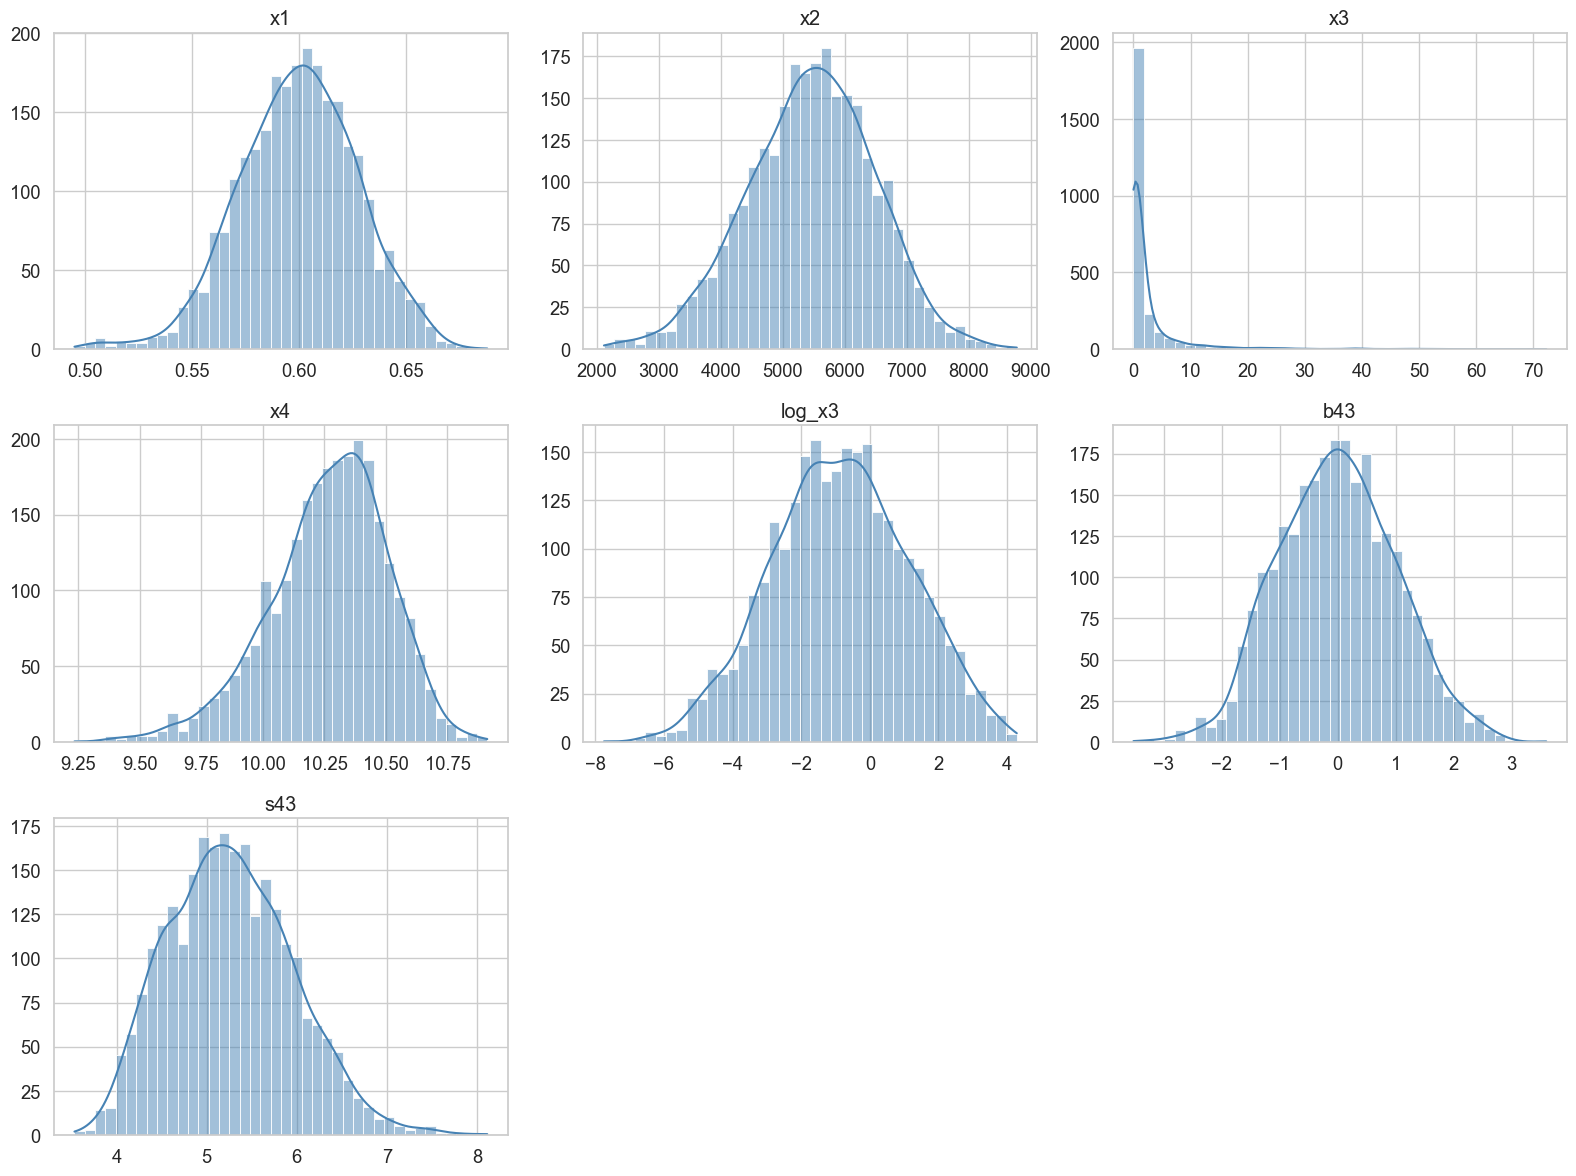

In [849]:
params = df.columns
n = len(params)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

for ax, param in zip(axes, params):
    sns.histplot(df[param], bins=40, kde=True, color="steelblue", ax=ax)
    ax.set_title(param)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Turn off any unused axes
for j in range(len(params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

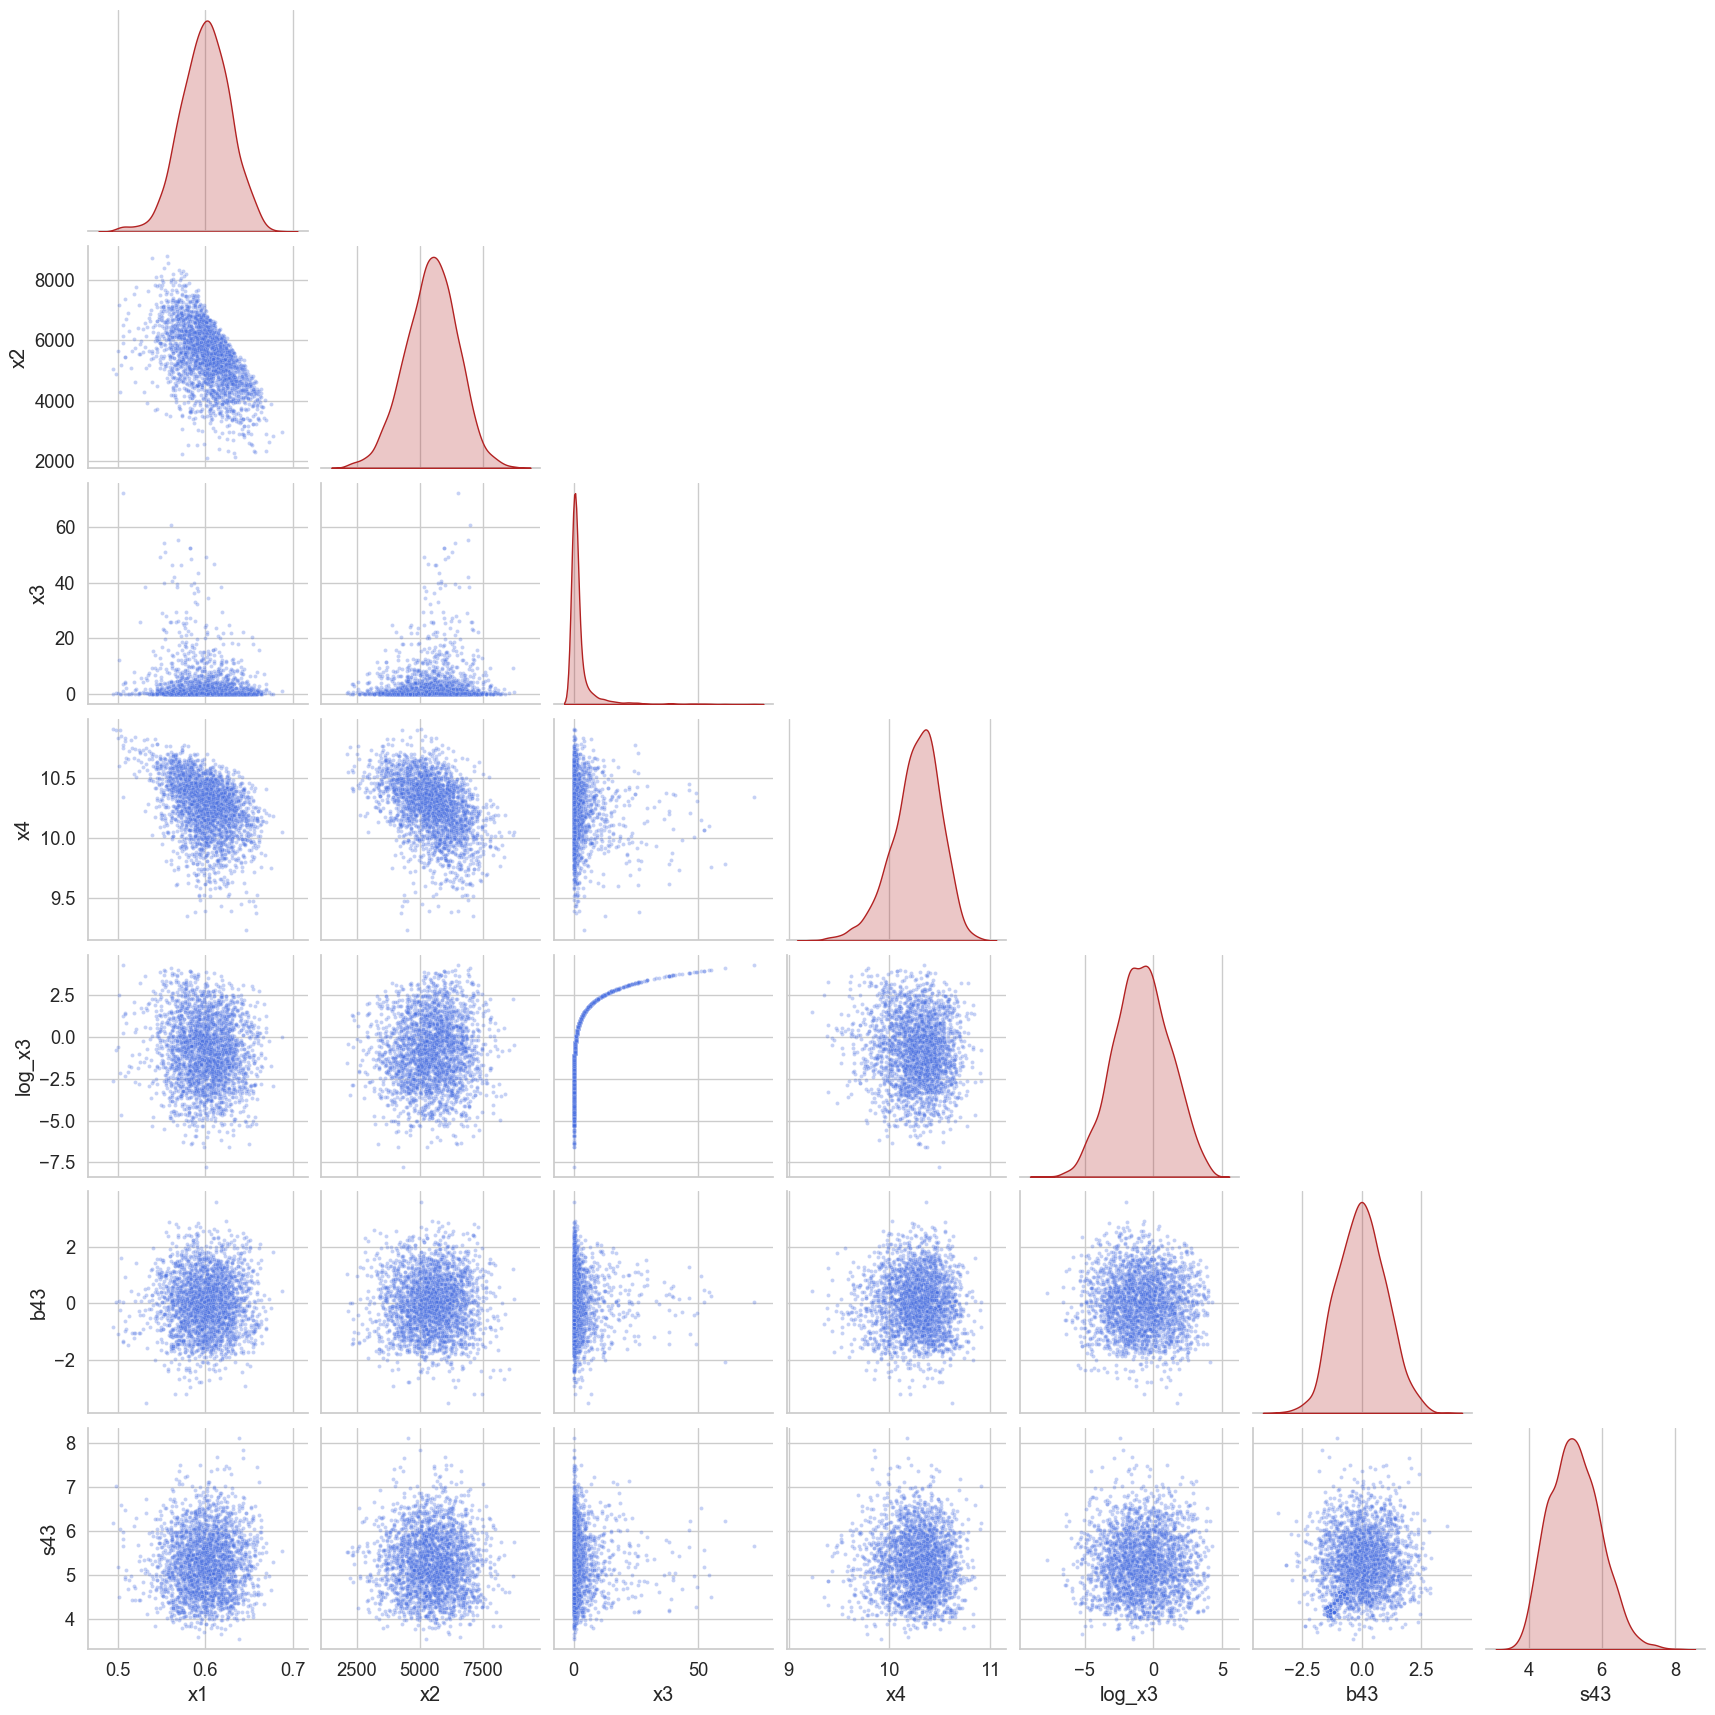

In [850]:
sns.pairplot(
    df,
    corner=True,
    diag_kind="kde",
    diag_kws=dict(fill=True, color="firebrick"),
    plot_kws=dict(s=8, alpha=0.3, color="royalblue")
)
plt.show()


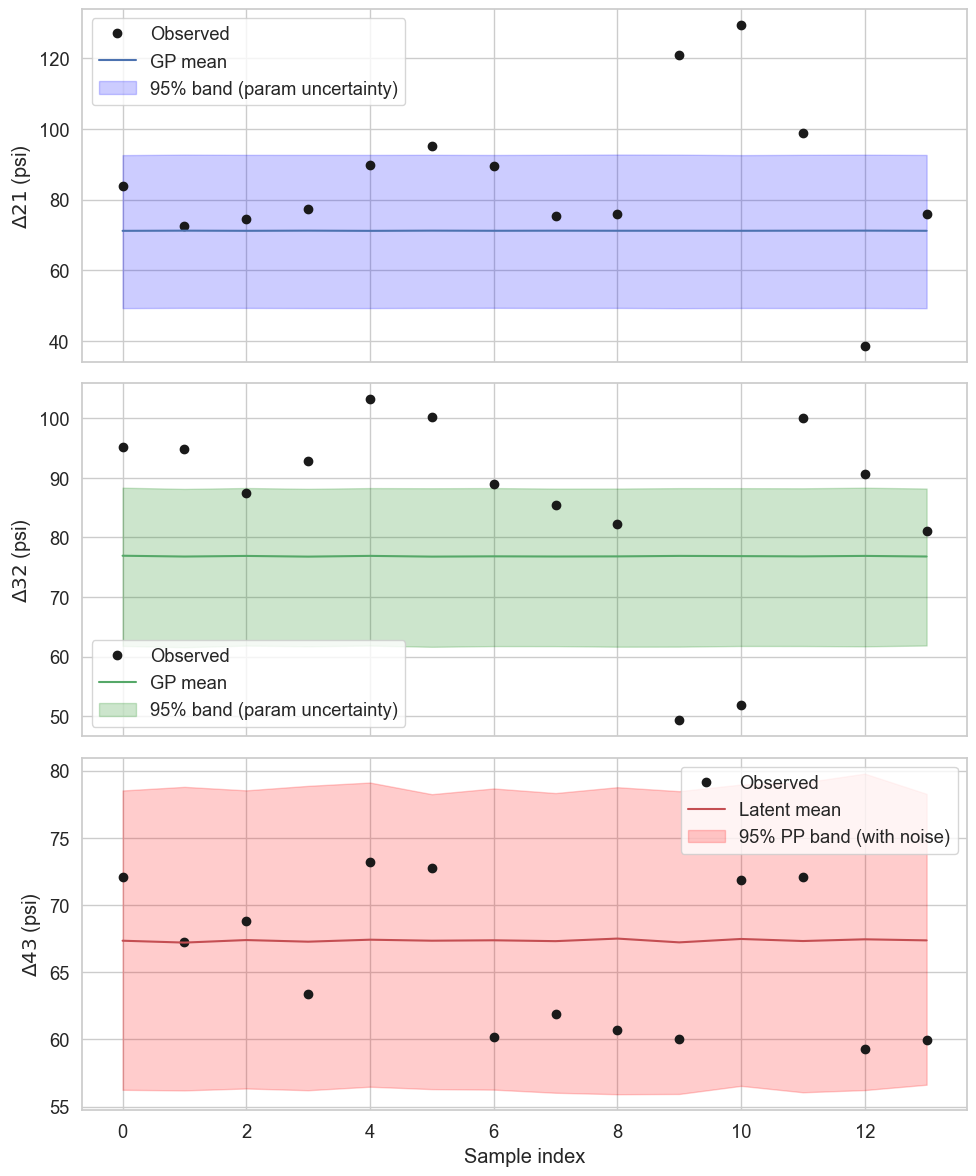

In [851]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# -----------------------------
# Extract posterior samples
# -----------------------------
x1_s  = df["x1"].values             # GP-scale x1 (as you stored it)
x2_s  = df["x2"].values * 10.0      # reverse earlier division, back to model scale if needed
x3_s  = df["x3"].values
x4_s  = df["x4"].values

b43_s = df["b43"].values
s43_s = df["s43"].values

nsamp = len(df)

# ---------------------------------------------
# Compute posterior predictive for each sample
# ---------------------------------------------
def predict_deltas(x1, x2, x3, x4, F):
    # Adjust these calls if your gp_flow_maps expects scaled x1/x2
    f1 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 0]) / 6894.76
    f2 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 1]) / 6894.76
    f3 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 2]) / 6894.76
    f4 = gp_flow_maps(x1,      x2,      x3, x4, F[:, 3]) / 6894.76

    d21 = f2 - f1
    d32 = f3 - f2
    d43 = f4 - f3
    return d21, d32, d43

# Storage
m21_all = []
m32_all = []
m43_all = []
y43_all = []

for i in range(nsamp):
    d21, d32, d43 = predict_deltas(
        x1_s[i], x2_s[i] / 10.0, x3_s[i], x4_s[i], F
    )

    # Δ21 and Δ32: mean predictions only from GP (no bias)
    m21 = d21
    m32 = d32

    # Δ43: latent mean has bias
    m43 = d43 + b43_s[i]

    # noisy posterior predictive ONLY for Δ43
    y43 = m43 + np.random.normal(0, s43_s[i], size=len(m43))

    m21_all.append(m21)
    m32_all.append(m32)
    m43_all.append(m43)
    y43_all.append(y43)

# Convert to arrays (nsamp, N)
m21_all = np.vstack(m21_all)
m32_all = np.vstack(m32_all)
m43_all = np.vstack(m43_all)
y43_all = np.vstack(y43_all)

# ---------------------------------------------
# Compute posterior predictive summaries
# ---------------------------------------------
def summarise(arr):
    return (
        np.mean(arr, axis=0),
        np.percentile(arr, 2.5, axis=0),
        np.percentile(arr, 97.5, axis=0),
    )

# Δ43: we have both latent mean and noisy predictive
m43_mean, m43_lo, m43_hi = summarise(m43_all)
y43_mean, y43_lo, y43_hi = summarise(y43_all)

# Δ21, Δ32: only parameter-uncertainty bands from m21, m32
m21_mean, m21_lo, m21_hi = summarise(m21_all)
m32_mean, m32_lo, m32_hi = summarise(m32_all)

# Observed
d21_obs = D[:, 0]
d32_obs = D[:, 1]
d43_obs = D[:, 2]

# ---------------------------------------------
# Plot posterior predictive bands
# ---------------------------------------------
x = np.arange(len(F))

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Δ21: GP-only (no noise calibration)
ax = axes[0]
ax.plot(x, d21_obs, "ko", label="Observed")
ax.plot(x, m21_mean, "b-", label="GP mean")
ax.fill_between(x, m21_lo, m21_hi, color="blue", alpha=0.2,
                label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 21$ (psi)")
ax.legend()

# Δ32: GP-only (no noise calibration)
ax = axes[1]
ax.plot(x, d32_obs, "ko", label="Observed")
ax.plot(x, m32_mean, "g-", label="GP mean")
ax.fill_between(x, m32_lo, m32_hi, color="green", alpha=0.2,
                label="95% band (param uncertainty)")
ax.set_ylabel(r"$\Delta 32$ (psi)")
ax.legend()

# Δ43: full posterior predictive
ax = axes[2]
ax.plot(x, d43_obs, "ko", label="Observed")
ax.plot(x, m43_mean, "r-", label="Latent mean")
ax.fill_between(x, y43_lo, y43_hi, color="red", alpha=0.2,
                label="95% PP band (with noise)")
ax.set_ylabel(r"$\Delta 43$ (psi)")
ax.set_xlabel("Sample index")
ax.legend()

plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


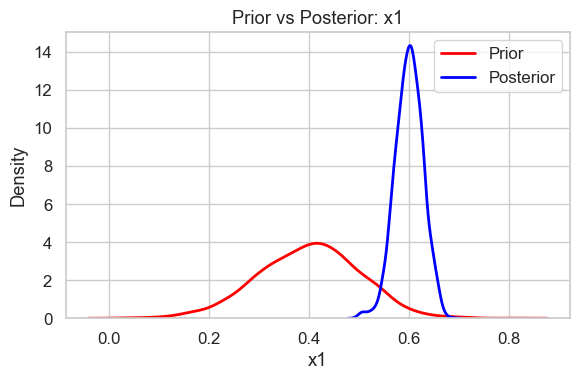

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


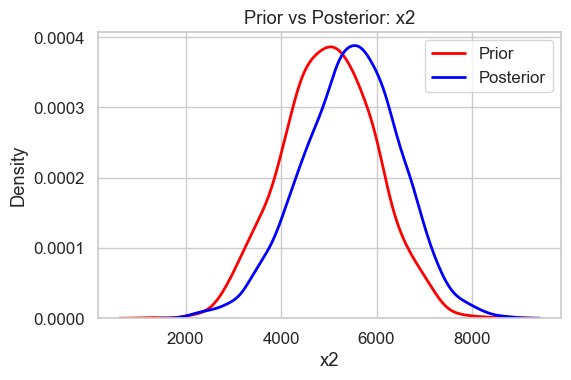

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


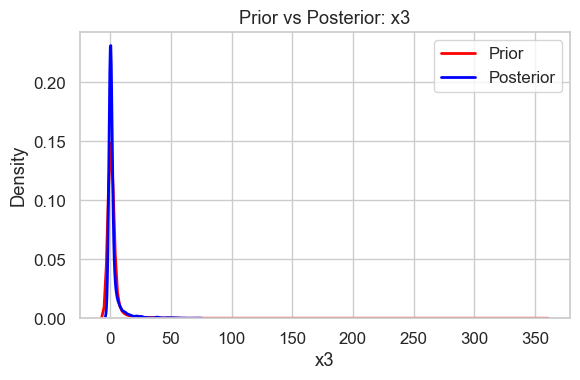

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


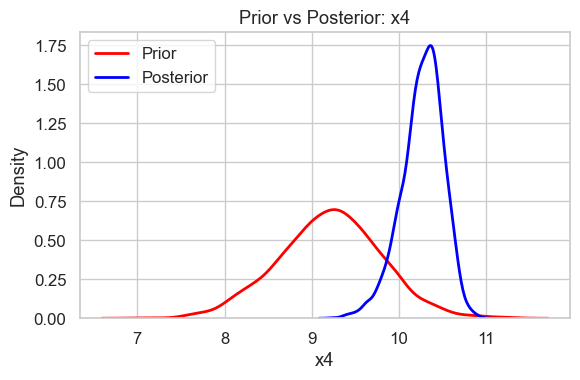

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


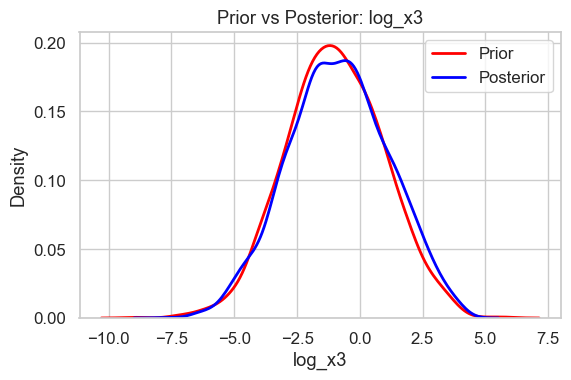

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


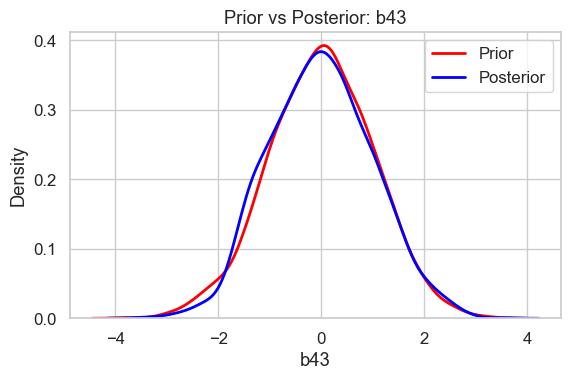

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


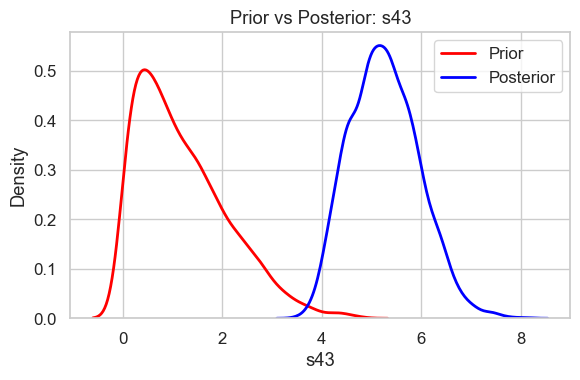

In [852]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

params = ["x1", "x2", "x3", "x4", "log_x3", "b43", "s43",]

for param in params:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df_prior[param], label="Prior", color="red", lw=2)
    sns.kdeplot(df[param],       label="Posterior", color="blue", lw=2)
    plt.title(f"Prior vs Posterior: {param}")
    plt.xlabel(param)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [853]:
df.to_csv("posterior_samples_delta43.csv", index=False)
df_prior.to_csv("prior_samples_delta43.csv", index=False)

print("Saved posterior_samples.csv and prior_samples.csv")

Saved posterior_samples.csv and prior_samples.csv


In [863]:
import pandas as pd

df_prior = pd.read_csv("prior_samples_delta43.csv")      # or delta21, whichever you saved
post21    = pd.read_csv("posterior_samples_delta21.csv")
post43    = pd.read_csv("posterior_samples_delta43.csv")

print(df_prior.head())

         x1         x2        x3        x4    log_x3       b43       s43
0  0.457573  4957.4053  0.630753  9.137889 -0.460841  0.384647  1.292406
1  0.448919  5979.2340  0.029810  9.329538 -3.512919 -0.020355  1.047144
2  0.249714  5252.3230  2.335710  8.274053  0.848316 -0.175773  1.918535
3  0.438283  4336.8380  0.017581  9.670922 -4.040934  1.230969  0.291747
4  0.335213  5519.8594  0.153402  9.217848 -1.874691  0.007216  1.698671


Loaded Δ21 posterior: (2600, 7)
Loaded Δ43 posterior: (2600, 7)


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


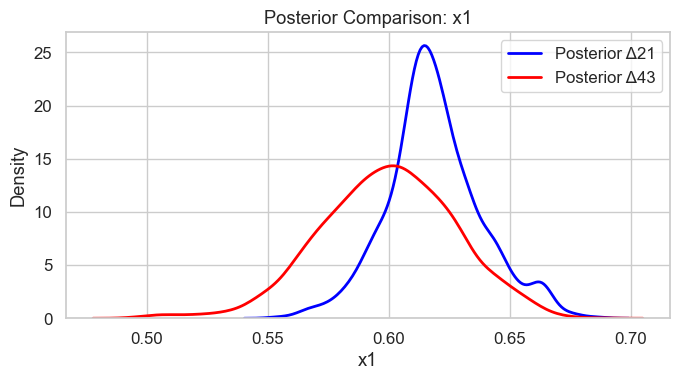

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


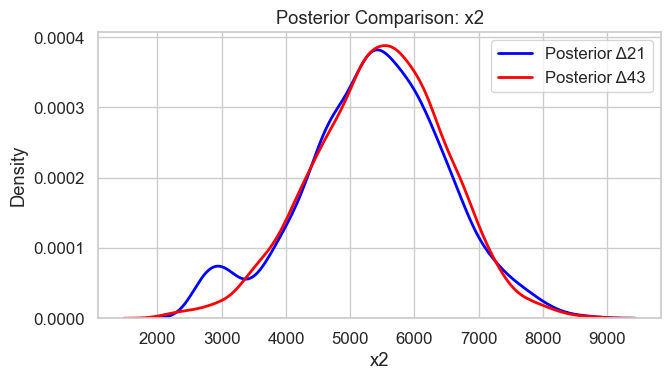

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


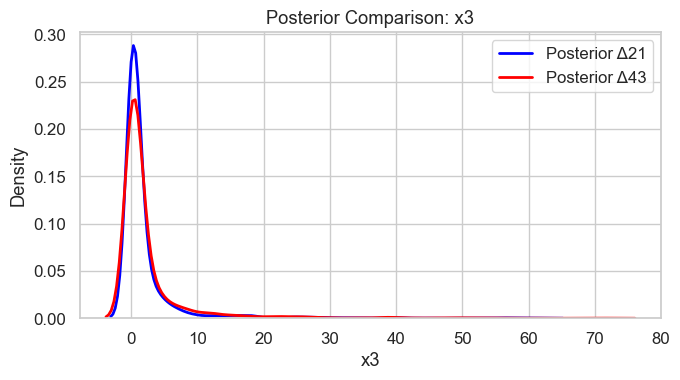

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


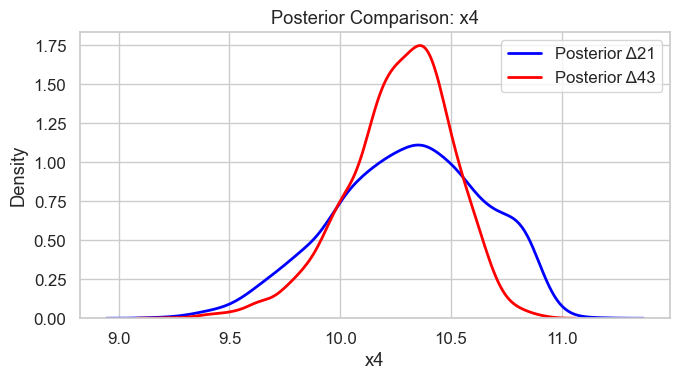

AttributeError: 'DataFrame' object has no attribute 'append'

In [854]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------
# Load posterior samples for delta21 & delta43
# -----------------------------------------
post21 = pd.read_csv("posterior_samples_delta21.csv")
post43 = pd.read_csv("posterior_samples_delta43.csv")

# If your CSV uses different names adjust here
params = ["x1", "x2", "x3", "x4"]

print("Loaded Δ21 posterior:", post21.shape)
print("Loaded Δ43 posterior:", post43.shape)

# -----------------------------------------
# KDE comparison plots
# -----------------------------------------
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

for p in params:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(post21[p], label="Posterior Δ21", color="blue", lw=2)
    sns.kdeplot(post43[p], label="Posterior Δ43", color="red", lw=2)
    plt.title(f"Posterior Comparison: {p}")
    plt.xlabel(p)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------------------
# Summary table: posterior mean & std
# -----------------------------------------
summary = pd.DataFrame(columns=["Parameter", 
                                "Δ21_mean", "Δ21_std", 
                                "Δ43_mean", "Δ43_std"])

for p in params:
    summary = summary.append({
        "Parameter": p,
        "Δ21_mean": post21[p].mean(),
        "Δ21_std": post21[p].std(),
        "Δ43_mean": post43[p].mean(),
        "Δ43_std": post43[p].std()
    }, ignore_index=True)

print("\nPosterior comparison (means & stds):\n")
print(summary.to_string(index=False))


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

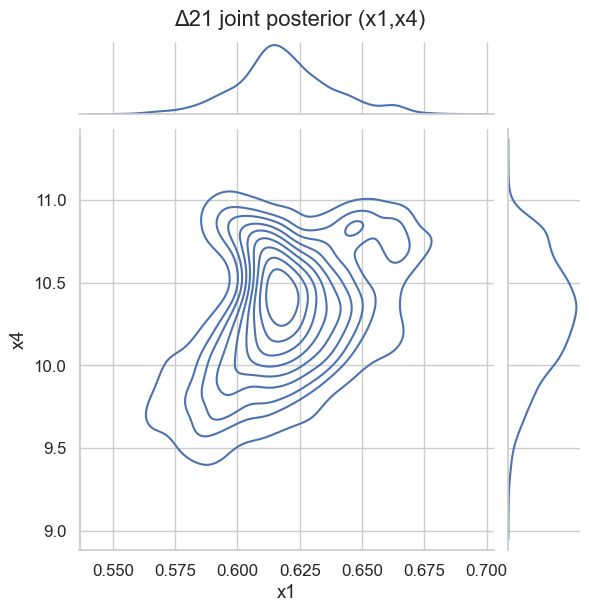

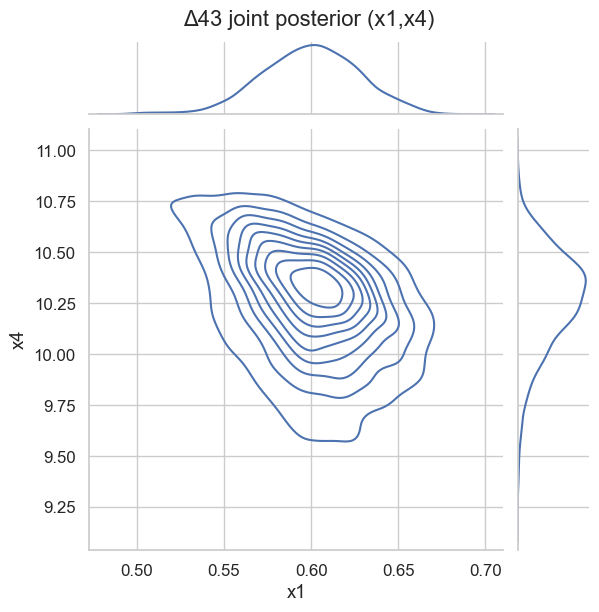

In [855]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(data=post21, x="x1", y="x4", kind="kde")
plt.suptitle("Δ21 joint posterior (x1,x4)", y=1.02)

sns.jointplot(data=post43, x="x1", y="x4", kind="kde")
plt.suptitle("Δ43 joint posterior (x1,x4)", y=1.02)
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

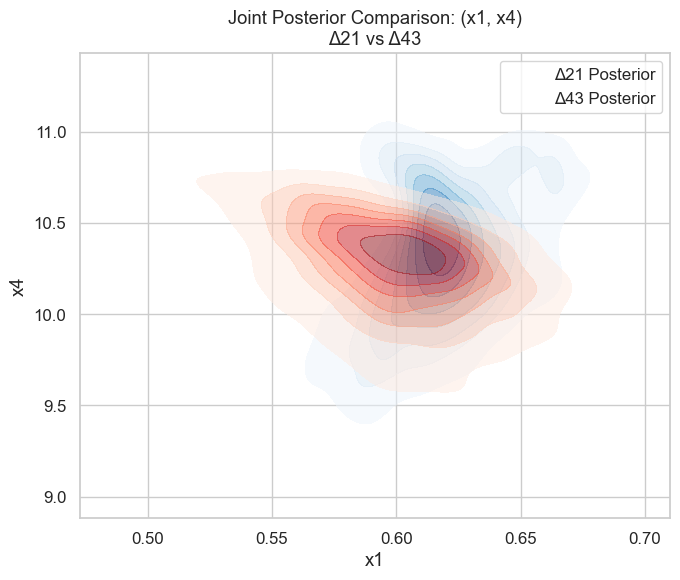

In [858]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Δ21 joint posterior (blue)
sns.kdeplot(
    x=post21["x1"], 
    y=post21["x4"], 
    cmap="Blues", 
    levels=8, 
    fill=True, 
    alpha=0.5, 
    label="Δ21 Posterior"
)

# Δ43 joint posterior (red)
sns.kdeplot(
    x=post43["x1"], 
    y=post43["x4"], 
    cmap="Reds", 
    levels=8, 
    fill=True, 
    alpha=0.5, 
    label="Δ43 Posterior"
)

plt.xlabel("x1")
plt.ylabel("x4")
plt.title("Joint Posterior Comparison: (x1, x4)\nΔ21 vs Δ43")
plt.legend()
plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

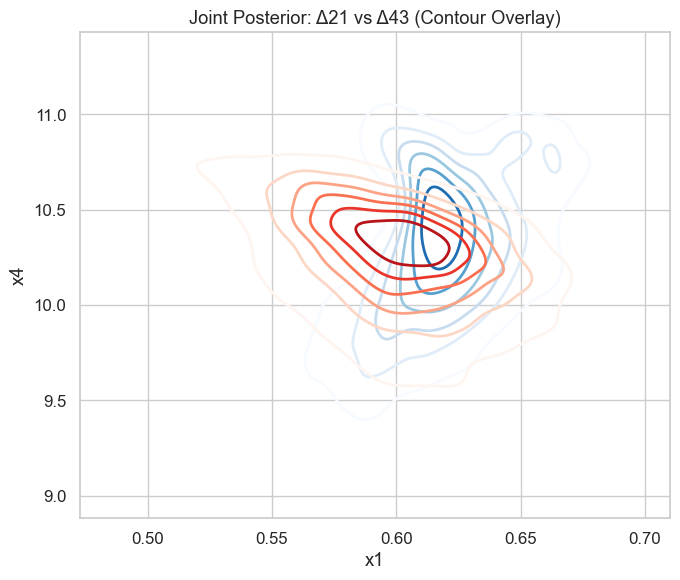

In [859]:
plt.figure(figsize=(7,6))

# Δ21 (blue contours)
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    cmap="Blues", levels=7, fill=False, linewidths=2, label="Δ21"
)

# Δ43 (red contours)
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    cmap="Reds", levels=7, fill=False, linewidths=2, label="Δ43"
)

plt.xlabel("x1")
plt.ylabel("x4")
plt.title("Joint Posterior: Δ21 vs Δ43 (Contour Overlay)")
plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py

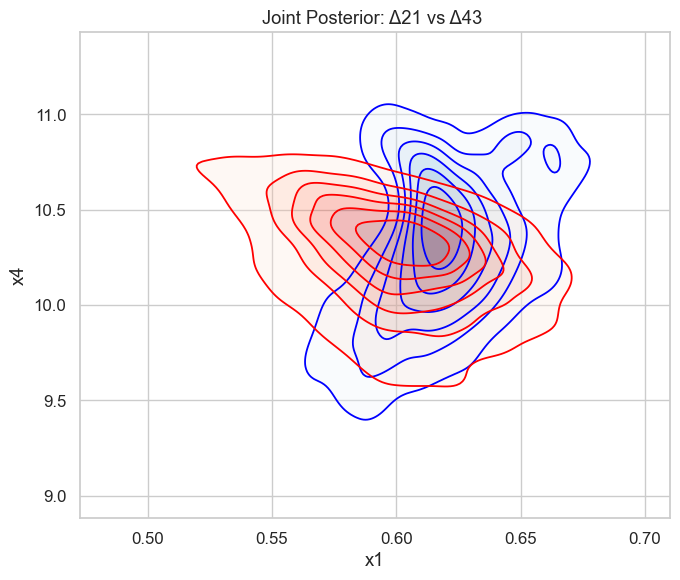

In [861]:
plt.figure(figsize=(7,6))

# Δ21 (blue)
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    cmap="Blues", levels=7, fill=True, alpha=0.3, thresh=0.05
)
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    color="blue", levels=7, fill=False, linewidths=1.3
)

# Δ43 (red)
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    cmap="Reds", levels=7, fill=True, alpha=0.3, thresh=0.05
)
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    color="red", levels=7, fill=False, linewidths=1.3
)

plt.xlabel("x1")
plt.ylabel("x4")
plt.title("Joint Posterior: Δ21 vs Δ43 ")
plt.tight_layout()
plt.show()


/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cset = contour_func(
/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version.

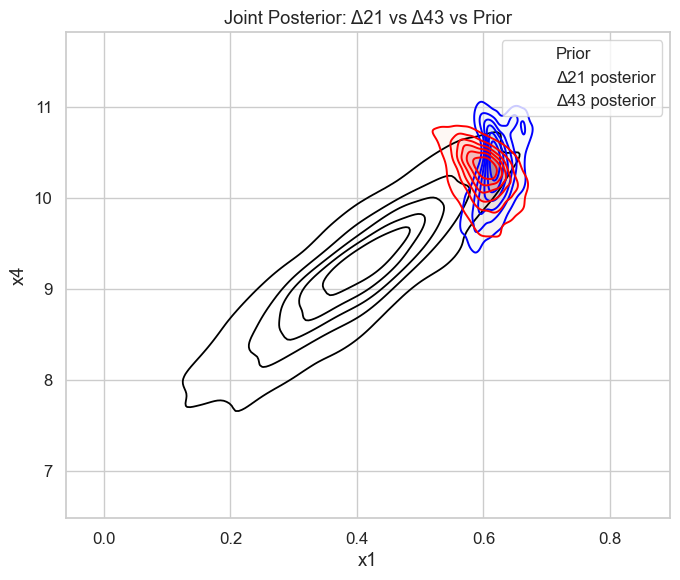

In [864]:
plt.figure(figsize=(7,6))

# -------------------------
# PRIOR (gray contours)
# -------------------------
sns.kdeplot(
    x=df_prior["x1"], y=df_prior["x4"],
    color="black",
    levels=6,
    fill=False,
    linestyle="--",
    linewidths=1.3,
    label="Prior"
)

# -------------------------
# Δ21 (blue)
# -------------------------
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    cmap="Blues", levels=7, fill=True, alpha=0.30, thresh=0.05
)
sns.kdeplot(
    x=post21["x1"], y=post21["x4"],
    color="blue", levels=7, fill=False, linewidths=1.4,
    label="Δ21 posterior"
)

# -------------------------
# Δ43 (red)
# -------------------------
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    cmap="Reds", levels=7, fill=True, alpha=0.30, thresh=0.05
)
sns.kdeplot(
    x=post43["x1"], y=post43["x4"],
    color="red", levels=7, fill=False, linewidths=1.4,
    label="Δ43 posterior"
)

plt.xlabel("x1")
plt.ylabel("x4")
plt.title("Joint Posterior: Δ21 vs Δ43 vs Prior")
plt.legend()
plt.tight_layout()
plt.show()
